# **Analyse de marche chez enfants autistes et non atypiques**

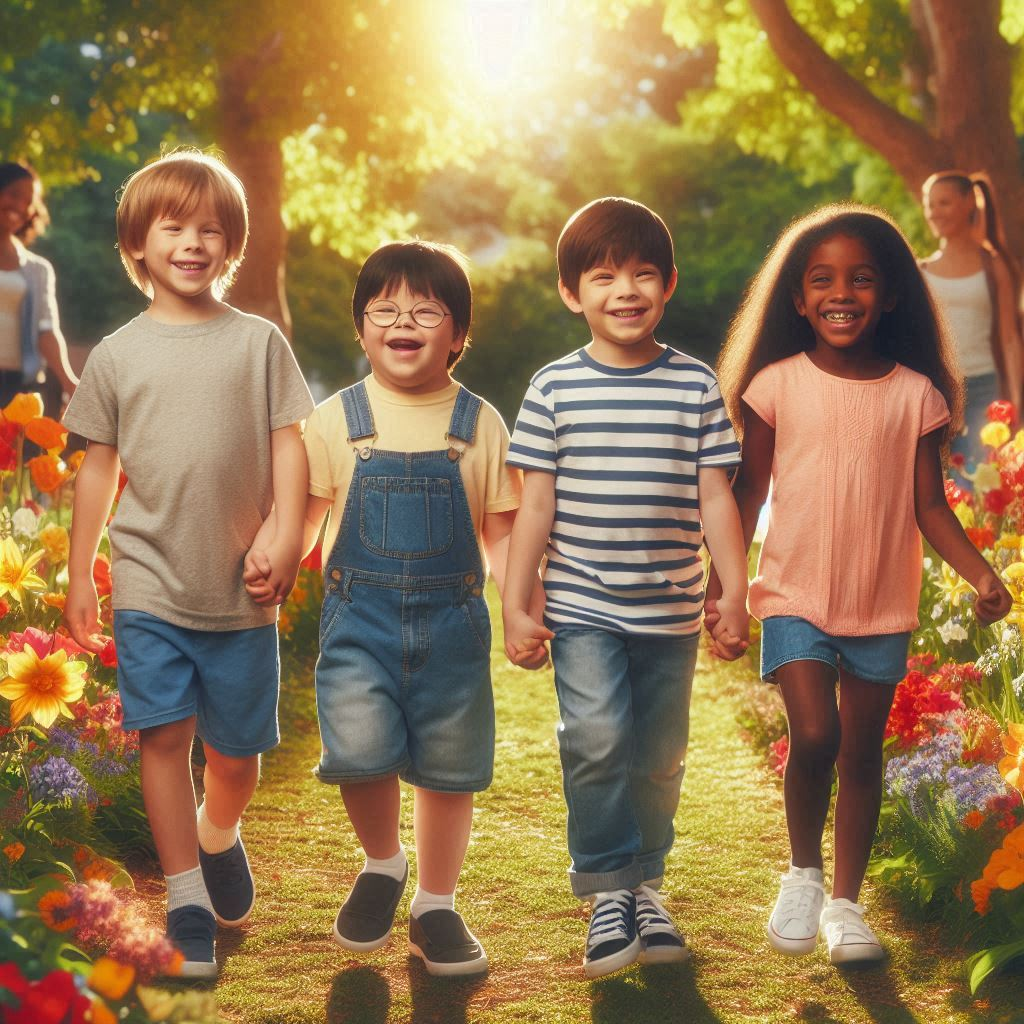

In [114]:
# -*- coding: utf-8 -*-
"""
Auteur : Kaze Carmelle & Fagla Pamela
Objet : Analyse exploratoire
Date : 20/03/2025

Nous allons faire une analyse exploratoire des données.

* Préparer les données TSA/NT.
* Décrire les données (tableaux/graphiques) par groupe.
* Comparer les groupes NT vs TSA (test stat.).
* Explorer le lien anticipation vs scores TSA (méthode stat.).
* Chercher clusters d'enfants (méthode stat.).
* Conclure sur l'effet du TSA.
"""

"\nAuteur : Kaze Carmelle & Fagla Pamela\nObjet : Analyse exploratoire\nDate : 20/03/2025\n\nNous allons faire une analyse exploratoire des données.\n\n* Préparer les données TSA/NT.\n* Décrire les données (tableaux/graphiques) par groupe.\n* Comparer les groupes NT vs TSA (test stat.).\n* Explorer le lien anticipation vs scores TSA (méthode stat.).\n* Chercher clusters d'enfants (méthode stat.).\n* Conclure sur l'effet du TSA.\n"

In [115]:
#Importations des libraries

import pandas as pd
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
from sklearn.impute import KNNImputer
from scipy.stats.mstats import winsorize
from scipy.stats import zscore
from collections import Counter

## **1.Importation des variables et présentation global de cette base**

In [116]:
# importer les données de mon google drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
#le chemin d'accès à votre fichier CSV sur Google Drive
file_path = '/content/drive/My Drive/etude_de_cas2/RES_all_cleaned2.xlsx'
#importation du fichier
df = pd.read_excel(file_path, sheet_name=1)
df.head()  # Affiche les 5 premières lignes du DataFrame

,GROUPE,Sujet,Age,Sexe,TAju(ms),TLoad(ms),TUnload(ms),CoP_tot_AP(/Long),CoP_tot_ML(/Larg),CoP_loadAP(/Long),...,MOT,RRB,SCI,TOT,Communication,Inter Sociale Reciproque,Total_Affect social,Score CRR,SIM,MAT
0,TSA,TSA1,11.4,1,566,303,263,0.017740,0.070734,0.061883,...,73.0,83.0,74.0,77.0,1.0,5.0,6.0,2,NaN,5.0
1,TSA,TSA2,11.2,2,481,215,266,0.043558,0.061563,0.090607,...,78.0,88.0,86.0,87.0,2.0,6.0,8.0,1,NaN,NaN
2,TSA,TSA3,7.1,2,461,245,216,0.048982,0.081928,0.266414,...,58.0,52.0,61.0,60.0,0.0,7.0,7.0,4,NaN,NaN
3,TSA,TSA4,7.0,2,643,308,335,0.059877,0.194656,0.042470,...,69.0,84.0,74.0,77.0,4.0,15.0,19.0,2,NaN,NaN
4,TSA,TSA5,6.9,1,329,166,163,0.049908,0.130384,0.168423,...,56.0,83.0,78.0,80.0,1.0,8.0,NaN,2,NaN,NaN


In [118]:
df.describe()

,Age,Sexe,TAju(ms),TLoad(ms),TUnload(ms),CoP_tot_AP(/Long),CoP_tot_ML(/Larg),CoP_loadAP(/Long),CoP_load_ML(/Larg),CoP_unload_ML(/Larg),...,COM,MOT,RRB,SCI,TOT,Communication,Inter Sociale Reciproque,Total_Affect social,SIM,MAT
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,...,32.000000,32.00000,32.00000,32.000000,32.000000,30.000000,30.000000,28.000000,35.000000,40.000000
mean,8.682167,1.466667,530.383333,290.433333,239.950000,0.042923,0.111806,0.183302,0.155281,0.322616,...,70.937500,66.65625,74.09375,72.406250,72.875000,2.566667,8.000000,10.607143,12.371429,11.825000
std,1.733578,0.503098,116.544178,97.015701,92.987775,0.014992,0.032281,0.090824,0.067133,0.092762,...,13.065437,11.98550,14.93936,12.597643,13.345895,1.524135,2.716489,3.975287,2.377415,2.890191
min,6.000000,1.000000,273.000000,134.000000,75.000000,0.014398,0.061563,-0.005183,0.028555,0.152177,...,39.000000,38.00000,41.00000,37.000000,37.000000,0.000000,3.000000,4.000000,5.000000,5.000000
25%,7.097500,1.000000,460.250000,225.750000,171.750000,0.032204,0.088837,0.112490,0.103741,0.269237,...,67.000000,58.00000,65.50000,69.000000,67.750000,1.000000,6.250000,7.750000,11.000000,10.000000
50%,8.800000,1.000000,524.000000,272.500000,223.500000,0.042676,0.107805,0.173975,0.147131,0.321443,...,72.000000,69.00000,76.00000,74.000000,77.000000,2.500000,7.500000,10.500000,13.000000,12.000000
75%,10.132500,2.000000,584.250000,332.000000,287.500000,0.052765,0.128804,0.247218,0.181916,0.360358,...,78.500000,73.50000,88.00000,79.000000,82.250000,4.000000,10.000000,13.250000,14.000000,14.000000
max,11.500000,2.000000,840.000000,617.000000,519.000000,0.076906,0.225527,0.501738,0.381614,0.817811,...,90.000000,86.00000,90.00000,90.000000,90.000000,6.000000,15.000000,19.000000,16.000000,19.000000


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GROUPE                        60 non-null     object 
 1   Sujet                         60 non-null     object 
 2   Age                           60 non-null     float64
 3   Sexe                          60 non-null     int64  
 4   TAju(ms)                      60 non-null     int64  
 5   TLoad(ms)                     60 non-null     int64  
 6   TUnload(ms)                   60 non-null     int64  
 7   CoP_tot_AP(/Long)             60 non-null     float64
 8   CoP_tot_ML(/Larg)             60 non-null     float64
 9   CoP_loadAP(/Long)             60 non-null     float64
 10  CoP_load_ML(/Larg)            60 non-null     float64
 11  CoP_unload_ML(/Larg)          60 non-null     float64
 12  Vpic_load_AP(m/s)             60 non-null     float64
 13  Vpic_lo

In [120]:
df.columns

Index(['GROUPE', 'Sujet', 'Age', 'Sexe', 'TAju(ms)', 'TLoad(ms)',
       'TUnload(ms)', 'CoP_tot_AP(/Long)', 'CoP_tot_ML(/Larg)',
       'CoP_loadAP(/Long)', 'CoP_load_ML(/Larg)', 'CoP_unload_ML(/Larg)',
       'Vpic_load_AP(m/s)', 'Vpic_load_ML(m/s)', 'Vpic_unload_ML(m/s)',
       'BOS_AP_Init(m)', 'BOS_ML_Init(m)', 'MOS_AP_FOcr(/Long)',
       'MOS_ML_FOcr(/Larg)', 'Weight', 'Height', 'QTAC',
       'Index global Conners 3 Total', 'AWR', 'COG', 'COM', 'MOT', 'RRB',
       'SCI', 'TOT', 'Communication', 'Inter Sociale Reciproque',
       'Total_Affect social', 'Score CRR', 'SIM', 'MAT'],
      dtype='object')

Nous avons donc 36 variables pour 60 enfants. Ces variables sont de type objet, entier ou décimal. Tout semble normal, sauf pour la variable "Score CRR" qui contient que des valeurs de nombres entiers. A cet effet, convertissons cette variable :

In [121]:
# Conversion en numérique avec gestion des erreurs
df['Score CRR'] = pd.to_numeric(df['Score CRR'], errors='coerce')

# Conversion en entiers, en ignorant les NaN
df['Score CRR'] = df['Score CRR'].astype('Int64')

# Vérification du type de données après conversion
print(df['Score CRR'].dtypes)

Int64


##  **2.1. Méthodologie utilisée pour l’appariement**


### **Étape 1 : Vérification des statistiques descriptives**

In [122]:
# Séparer les groupes
df_nt = df[df['GROUPE'] == 'TD']
df_tsa = df[df['GROUPE'] == 'TSA']

# Variables d’appariement
variables = ['Age', 'Height', 'Weight']

# Afficher les statistiques descriptives
print("Statistiques descriptives - NT")
print(df_nt[variables].describe())

print("\nStatistiques descriptives - TSA")
print(df_tsa[variables].describe())

Statistiques descriptives - NT
             Age      Height    Weight
count  30.000000   30.000000  30.00000
mean    8.609333  134.733333  28.76500
std     1.714623   10.578714   6.02319
min     6.000000  116.500000  19.30000
25%     7.137500  128.000000  24.15000
50%     8.350000  133.500000  29.00000
75%    10.177500  140.250000  33.00000
max    11.080000  157.000000  41.00000

Statistiques descriptives - TSA
             Age      Height     Weight
count  30.000000   27.000000  30.000000
mean    8.755000  133.500000  29.803088
std     1.778569   14.723738  11.965069
min     6.050000  110.000000  17.252903
25%     7.025000  124.500000  20.902882
50%     8.940000  130.000000  28.621237
75%    10.090000  144.000000  32.636216
max    11.500000  173.500000  68.266496


### **Étape 2 : Tests de comparaison (Tests statistiques)**

In [123]:
# Vérifier la normalité des données avec le test de Shapiro-Wilk en ignorant les NA
for var in variables:
    stat_nt, p_nt = shapiro(df_nt[var].dropna())  # Suppression des NA
    stat_tsa, p_tsa = shapiro(df_tsa[var].dropna())  # Suppression des NA
    print(f"{var} - p-value Shapiro NT : {p_nt:.4f}, TSA : {p_tsa:.4f}")

# Effectuer les tests statistiques en ignorant les NA
for var in variables:
    nt_clean = df_nt[var].dropna()  # Suppression des NA
    tsa_clean = df_tsa[var].dropna()  # Suppression des NA

    # Si les données sont normales, on fait un test t de Student
    if p_nt > 0.05 and p_tsa > 0.05:
        stat, p_value = ttest_ind(nt_clean, tsa_clean, equal_var=False)
        test_type = "Test t de Student"
    else:
        # Sinon, on fait un test de Mann-Whitney (test non paramétrique)
        stat, p_value = mannwhitneyu(nt_clean, tsa_clean)
        test_type = "Test de Mann-Whitney"

    print(f"{test_type} pour {var} - p-value : {p_value:.4f}")

    if p_value > 0.05:
        print(f"✅ Aucune différence significative sur {var}, l’appariement est correct.\n")
    else:
        print(f"⚠️ Différence significative détectée sur {var} ! L’appariement pourrait être problématique.\n")


Age - p-value Shapiro NT : 0.0133, TSA : 0.0183
Height - p-value Shapiro NT : 0.1103, TSA : 0.4787
Weight - p-value Shapiro NT : 0.2417, TSA : 0.0005
Test de Mann-Whitney pour Age - p-value : 0.8649
✅ Aucune différence significative sur Age, l’appariement est correct.

Test de Mann-Whitney pour Height - p-value : 0.5757
✅ Aucune différence significative sur Height, l’appariement est correct.

Test de Mann-Whitney pour Weight - p-value : 0.5443
✅ Aucune différence significative sur Weight, l’appariement est correct.



**Représentation du résultats des tests effectués**

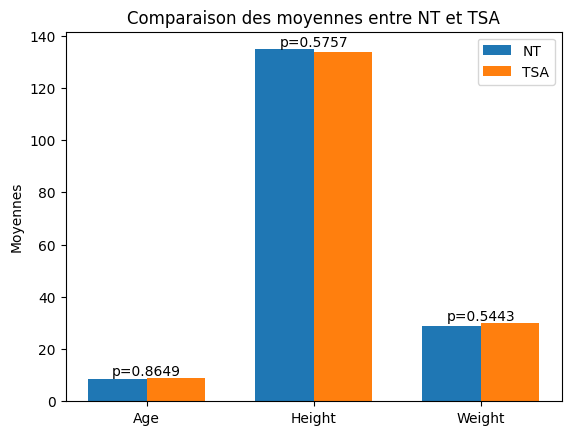

In [124]:

# Données (moyennes)
nt_means = [8.61, 134.73, 28.77]
tsa_means = [8.76, 133.50, 29.80]

# P-values
p_values = [0.8649, 0.5757, 0.5443]

# Création du graphique
x = np.arange(len(variables))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, nt_means, width, label='NT')
rects2 = ax.bar(x + width/2, tsa_means, width, label='TSA')

# Ajout des labels, titres et légende
ax.set_ylabel('Moyennes')
ax.set_title('Comparaison des moyennes entre NT et TSA')
ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.legend()

# Ajout des p-values (sous forme de texte)
for i, p in enumerate(p_values):
    ax.text(x[i], max(nt_means[i], tsa_means[i]) + 1, f'p={p:.4f}', ha='center')

plt.show()

### **Étape 3 : Visualisation**

<ipython-input-125-98dcebc1ff8d>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-125-98dcebc1ff8d>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-125-98dcebc1ff8d>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




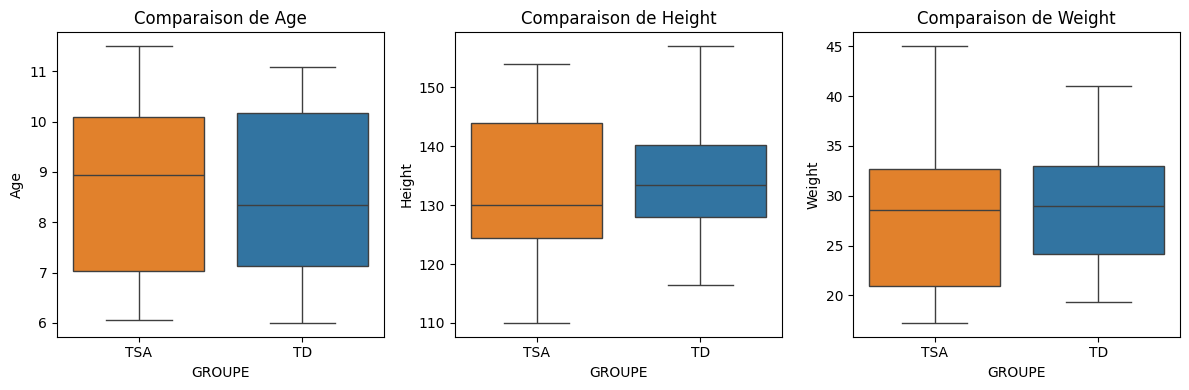

In [125]:
# Visualisation avec des boxplots
plt.figure(figsize=(12, 4))
for i, var in enumerate(variables, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='GROUPE', y=var, data=df, showfliers=False, palette=['#ff7f0e', '#1f77b4'])
    plt.title(f"Comparaison de {var}")
plt.tight_layout()
plt.show()

##  **Détection et correction des anomalies**
### **✅ 1. Vérification des valeurs manquantes (NA) et corrections**

In [126]:
# Calcul du nombre de valeurs manquantes par colonne
missing_values = df.isnull().sum()

# Création d'un DataFrame pour une meilleure lisibilité
missing_values_df = pd.DataFrame({'Variable': missing_values.index, 'Valeurs Manquantes': missing_values.values})

# Filtrer pour ne garder que les colonnes ayant au moins une valeur manquante
missing_values_df = missing_values_df[missing_values_df['Valeurs Manquantes'] > 0]

# Trier par ordre décroissant des valeurs manquantes
missing_values_df = missing_values_df.sort_values(by='Valeurs Manquantes', ascending=False)

# Affichage
missing_values_df

,Variable,Valeurs Manquantes
33,Score CRR,34
32,Total_Affect social,32
30,Communication,30
31,Inter Sociale Reciproque,30
23,AWR,28
26,MOT,28
25,COM,28
24,COG,28
28,SCI,28
29,TOT,28


In [127]:
# Affichage du nombre de variables avec le même nombre de valeurs manquantes
value_counts = missing_values_df['Valeurs Manquantes'].value_counts()
print("Nombre de variables par nombre de valeurs manquantes :")
value_counts

Nombre de variables par nombre de valeurs manquantes :


,count
Valeurs Manquantes,
28,7
30,2
3,2
32,1
34,1
25,1
20,1
2,1


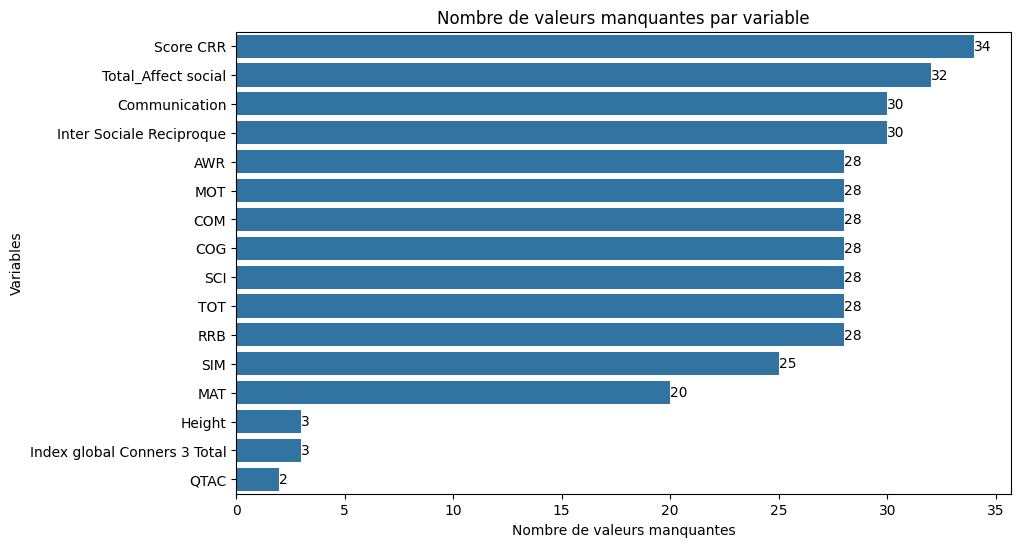

In [128]:
# Création du graphique à barres
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='Valeurs Manquantes', y='Variable', data=missing_values_df)
plt.title("Nombre de valeurs manquantes par variable")
plt.xlabel("Nombre de valeurs manquantes")
plt.ylabel("Variables")
# Ajouter le nombre d'outliers sur chaque barre
for bar in bars.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
             f'{int(bar.get_width())}', va='center')
plt.show()

**=> Correction des valeurs manquantes**

In [129]:
# Séparer les variables numériques et qualitatives
df_numeric = df.select_dtypes(include=['number'])
df_categorical = df.select_dtypes(exclude=['number'])

# Appliquer KNN Imputer (choix de k = 5, peut être ajusté)
knn_imputer = KNNImputer(n_neighbors=5)
df_numeric_imputed = pd.DataFrame(knn_imputer.fit_transform(df_numeric), columns=df_numeric.columns)

# Identifier les colonnes qui étaient entières dans df_numeric AVANT l'imputation
integer_columns = [col for col in df_numeric.columns if pd.api.types.is_integer_dtype(df_numeric[col])]

# Arrondir ces colonnes après l'imputation
df_numeric_imputed[integer_columns] = df_numeric_imputed[integer_columns].round().astype(int)

# Fusionner les données imputées avec les variables qualitatives
df1 = pd.concat([df_categorical, df_numeric_imputed], axis=1)

# Vérifier que toutes les colonnes sont bien réintégrées
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GROUPE                        60 non-null     object 
 1   Sujet                         60 non-null     object 
 2   Age                           60 non-null     float64
 3   Sexe                          60 non-null     int64  
 4   TAju(ms)                      60 non-null     int64  
 5   TLoad(ms)                     60 non-null     int64  
 6   TUnload(ms)                   60 non-null     int64  
 7   CoP_tot_AP(/Long)             60 non-null     float64
 8   CoP_tot_ML(/Larg)             60 non-null     float64
 9   CoP_loadAP(/Long)             60 non-null     float64
 10  CoP_load_ML(/Larg)            60 non-null     float64
 11  CoP_unload_ML(/Larg)          60 non-null     float64
 12  Vpic_load_AP(m/s)             60 non-null     float64
 13  Vpic_lo

**Vérification après l'imputation pour les valeurs manquantes**

In [130]:
# Vérification des valeurs manquantes après imputation
missing_values_after_imputation = df1.isnull().sum()

# Affichage du nombre de valeurs manquantes par colonne après imputation
print("Nombre de valeurs manquantes après imputation KNN :")
print(missing_values_after_imputation)

# Vérification s'il reste des valeurs manquantes
if missing_values_after_imputation.sum() == 0:
    print("\nIl n'y a plus de valeurs manquantes dans le DataFrame.")
else:
    print("\nIl reste des valeurs manquantes dans le DataFrame.")

Nombre de valeurs manquantes après imputation KNN :
GROUPE                          0
Sujet                           0
Age                             0
Sexe                            0
TAju(ms)                        0
TLoad(ms)                       0
TUnload(ms)                     0
CoP_tot_AP(/Long)               0
CoP_tot_ML(/Larg)               0
CoP_loadAP(/Long)               0
CoP_load_ML(/Larg)              0
CoP_unload_ML(/Larg)            0
Vpic_load_AP(m/s)               0
Vpic_load_ML(m/s)               0
Vpic_unload_ML(m/s)             0
BOS_AP_Init(m)                  0
BOS_ML_Init(m)                  0
MOS_AP_FOcr(/Long)              0
MOS_ML_FOcr(/Larg)              0
Weight                          0
Height                          0
QTAC                            0
Index global Conners 3 Total    0
AWR                             0
COG                             0
COM                             0
MOT                             0
RRB                           

Il n'y a plus de valeurs manquantes dans le DataFrame. Passons maintenant à la détection des valeurs aberrantes.

### **✅ 2. Détection des valeurs aberrantes**

Fonction qui combine Z-score et IQR pour une détection plus robuste


In [131]:
def detect_outliers(df, column, z_threshold=3, iqr_factor=1.5):
    """
    Combine Z-score et IQR pour une détection plus robuste
    """
    # Méthode Z-score
    z_scores = np.abs(zscore(df[column]))
    z_outliers = z_scores > z_threshold

    # Méthode IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr_factor * IQR
    upper_bound = Q3 + iqr_factor * IQR
    iqr_outliers = (df[column] < lower_bound) | (df[column] > upper_bound)

    # On considère comme outlier si les deux méthodes sont d'accord
    combined_outliers = z_outliers & iqr_outliers
    return combined_outliers

**Application pratique de la fonction detect_outliers**

Détection des outliers sur toutes les variables numériques :

In [132]:
# Liste des colonnes numériques
numeric_cols = df1.select_dtypes(include=['number']).columns

# Dictionnaire pour stocker les résultats
outliers_report = {}

for col in numeric_cols:
    outliers_mask = detect_outliers(df1, col)
    outliers_count = outliers_mask.sum()
    outliers_report[col] = {
        'count': outliers_count,
        'indices': df1[outliers_mask].index.tolist(),
        'values': df1.loc[outliers_mask, col].tolist()
    }

    print(f"{col}: {outliers_count} outliers détectés")

# Affichage synthétique
outliers_df = pd.DataFrame.from_dict(outliers_report, orient='index')
print("\nRécapitulatif des outliers:")
print(outliers_df.sort_values(by='count', ascending=False))

Age: 0 outliers détectés
Sexe: 0 outliers détectés
TAju(ms): 0 outliers détectés
TLoad(ms): 1 outliers détectés
TUnload(ms): 1 outliers détectés
CoP_tot_AP(/Long): 0 outliers détectés
CoP_tot_ML(/Larg): 1 outliers détectés
CoP_loadAP(/Long): 1 outliers détectés
CoP_load_ML(/Larg): 1 outliers détectés
CoP_unload_ML(/Larg): 1 outliers détectés
Vpic_load_AP(m/s): 1 outliers détectés
Vpic_load_ML(m/s): 1 outliers détectés
Vpic_unload_ML(m/s): 1 outliers détectés
BOS_AP_Init(m): 0 outliers détectés
BOS_ML_Init(m): 1 outliers détectés
MOS_AP_FOcr(/Long): 0 outliers détectés
MOS_ML_FOcr(/Larg): 1 outliers détectés
Weight: 2 outliers détectés
Height: 1 outliers détectés
QTAC: 0 outliers détectés
Index global Conners 3 Total: 0 outliers détectés
AWR: 0 outliers détectés
COG: 3 outliers détectés
COM: 0 outliers détectés
MOT: 1 outliers détectés
RRB: 0 outliers détectés
SCI: 1 outliers détectés
TOT: 1 outliers détectés
Communication: 1 outliers détectés
Inter Sociale Reciproque: 1 outliers détect

**Visualisation des outliers détectés :**

<ipython-input-133-ba5d5efc45b8>:3: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



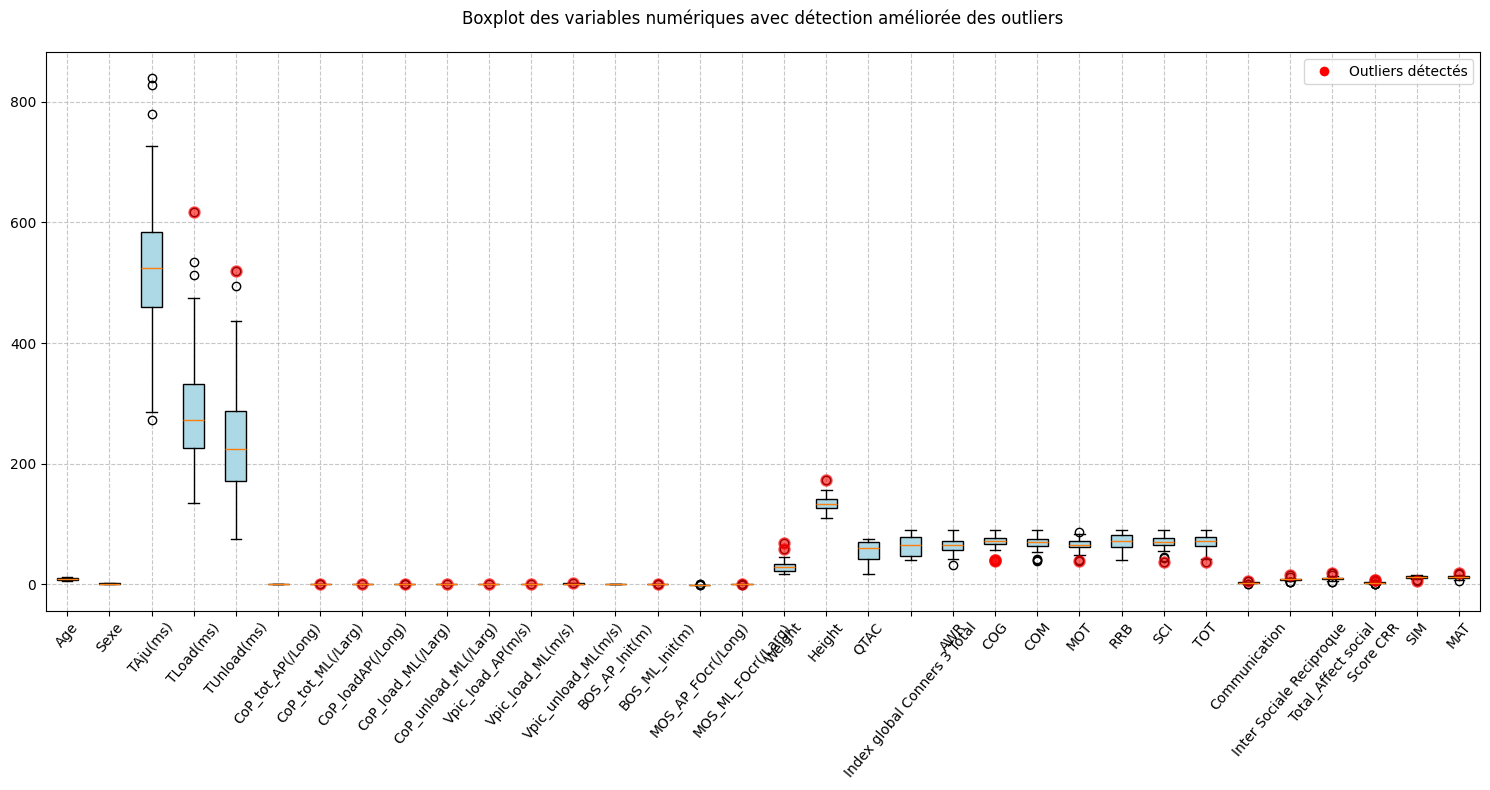

In [133]:
# Création du boxplot avec mise en évidence des outliers
plt.figure(figsize=(15, 8))
box = plt.boxplot(df1[numeric_cols].values, labels=numeric_cols, patch_artist=True, vert=True)
plt.xticks(rotation=50)
plt.title("Boxplot des variables numériques avec détection améliorée des outliers", pad=20)

# Paramètres visuels
colors = ['lightblue' for _ in numeric_cols]
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Marquage des outliers détectés par notre méthode combinée
for i, col in enumerate(numeric_cols):
    # Récupération des outliers selon notre méthode
    outliers_mask = detect_outliers(df1, col)
    outliers_values = df1.loc[outliers_mask, col]

    # Position x de la variable
    x_pos = i + 1

    # Marquage des vrais outliers (rouge)
    for val in outliers_values:
        plt.plot(x_pos, val, 'ro', alpha=0.6, markersize=8)

# Légende
red_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Outliers détectés')
plt.legend(handles=[red_patch], loc='upper right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Affichage de l'outlier

In [134]:
outlier_mask = detect_outliers(df1, 'CoP_tot_ML(/Larg)')
outlier_row = df1[outlier_mask]
print("Détails de l'outlier :")
display(outlier_row[['GROUPE', 'Sujet', 'Age', 'CoP_tot_ML(/Larg)']])

Détails de l'outlier :


,GROUPE,Sujet,Age,CoP_tot_ML(/Larg)
29,TSA,TSA30,10.06,0.225527


In [135]:
# Détection de l'outlier avec votre méthode combinée
outlier_value = df1.loc[outlier_mask, 'CoP_tot_ML(/Larg)'].values[0]  # Valeur numérique

print(f"Valeur de l'outlier : {outlier_value}")

Valeur de l'outlier : 0.22552716225556116


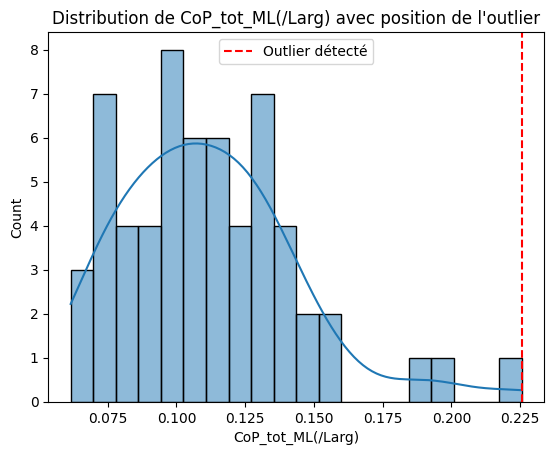

In [136]:
# 1. Créer l'histogramme
sns.histplot(df1['CoP_tot_ML(/Larg)'], kde=True, bins=20)

# 2. Ajouter une ligne rouge pour marquer l'outlier
plt.axvline(x=outlier_value, color='red', linestyle='--', label='Outlier détecté')

# 3. Afficher la légende et le titre
plt.legend()
plt.title("Distribution de CoP_tot_ML(/Larg) avec position de l'outlier")
plt.show()

✅ 3. Détection des incohérences


In [137]:
# 1. Vérification des valeurs aberrantes logiques
print("Valeurs d'âge en dehors de notre intervalle [6, 12]  ou anormales :")
print(df1[(df1['Age'] < 6) | (df1['Age'] > 12 ) ])  # Exclure si nécessaire

#2. Détecter les ratios improbables (ex. : IMC)
df1["IMC"] = df1["Weight"] / ((df1["Height"]/100)**2)
extreme_imc = df1[(df1["IMC"] < 10) | (df1["IMC"] > 30)]  # Plage enfance normale

# Afficher les résultats
print("\nIMC extrêmes :", extreme_imc[["Sujet", "Weight", "Height", "IMC"]])

Valeurs d'âge en dehors de notre intervalle [6, 12]  ou anormales :
Empty DataFrame
Columns: [GROUPE, Sujet, Age, Sexe, TAju(ms), TLoad(ms), TUnload(ms), CoP_tot_AP(/Long), CoP_tot_ML(/Larg), CoP_loadAP(/Long), CoP_load_ML(/Larg), CoP_unload_ML(/Larg), Vpic_load_AP(m/s), Vpic_load_ML(m/s), Vpic_unload_ML(m/s), BOS_AP_Init(m), BOS_ML_Init(m), MOS_AP_FOcr(/Long), MOS_ML_FOcr(/Larg), Weight, Height, QTAC, Index global Conners 3 Total, AWR, COG, COM, MOT, RRB, SCI, TOT, Communication, Inter Sociale Reciproque, Total_Affect social, Score CRR, SIM, MAT]
Index: []

[0 rows x 36 columns]

IMC extrêmes :     Sujet     Weight  Height        IMC
17  TSA18  17.723431   139.0   9.173144
23  TSA24  58.968182   134.9  32.403643


**✅ 4. Détection des doublons**

In [138]:
# Vérification des doublons
duplicates = df.duplicated().sum()
print(f"Nombre de doublons détectés : {duplicates}")


Nombre de doublons détectés : 0


Aucun doublon n'a été détecter, nous pourrions passez à l'analyse exploratoire des données.
Ci-dessous notre base après nettoyage.

In [139]:
df = df1.iloc[:, :-2]
df.head()

,GROUPE,Sujet,Age,Sexe,TAju(ms),TLoad(ms),TUnload(ms),CoP_tot_AP(/Long),CoP_tot_ML(/Larg),CoP_loadAP(/Long),...,COM,MOT,RRB,SCI,TOT,Communication,Inter Sociale Reciproque,Total_Affect social,Score CRR,SIM
0,TSA,TSA1,11.4,1,566,303,263,0.017740,0.070734,0.061883,...,69.0,73.0,83.0,74.0,77.0,1.0,5.0,6.0,2,13.8
1,TSA,TSA2,11.2,2,481,215,266,0.043558,0.061563,0.090607,...,90.0,78.0,88.0,86.0,87.0,2.0,6.0,8.0,1,10.6
2,TSA,TSA3,7.1,2,461,245,216,0.048982,0.081928,0.266414,...,59.0,58.0,52.0,61.0,60.0,0.0,7.0,7.0,4,10.0
3,TSA,TSA4,7.0,2,643,308,335,0.059877,0.194656,0.042470,...,74.0,69.0,84.0,74.0,77.0,4.0,15.0,19.0,2,13.0
4,TSA,TSA5,6.9,1,329,166,163,0.049908,0.130384,0.168423,...,78.0,56.0,83.0,78.0,80.0,1.0,8.0,8.6,2,11.2


## **Analyse exploratoire des données**

**🔍 Analyse Univariée**


In [140]:
# Calcul des statistiques descriptives
stats_df = df.describe().T  # Transposer pour une meilleure lecture

# Sélectionner et arrondir les statistiques pertinentes
stats_df = stats_df[['mean', 'std', 'min', '50%', 'max']].rename(columns={'50%': 'median'})
stats_df = stats_df.round(2)

# Afficher les résultats
stats_df

,mean,std,min,median,max
Age,8.68,1.73,6.00,8.80,11.50
Sexe,1.47,0.50,1.00,1.00,2.00
TAju(ms),530.38,116.54,273.00,524.00,840.00
TLoad(ms),290.43,97.02,134.00,272.50,617.00
TUnload(ms),239.95,92.99,75.00,223.50,519.00
CoP_tot_AP(/Long),0.04,0.01,0.01,0.04,0.08
CoP_tot_ML(/Larg),0.11,0.03,0.06,0.11,0.23
CoP_loadAP(/Long),0.18,0.09,-0.01,0.17,0.50
CoP_load_ML(/Larg),0.16,0.07,0.03,0.15,0.38
CoP_unload_ML(/Larg),0.32,0.09,0.15,0.32,0.82


**1. Variables Numériques**

Les variables numériques sont analysées avec des graphiques permettant d'étudier leur distribution, dispersion et concentration.

**📊 Histogramme (Distribution des valeurs)**

**Objectif :** Vérifier la forme de la distribution (Normale, asymétrique, etc.).

<Figure size 1200x800 with 0 Axes>

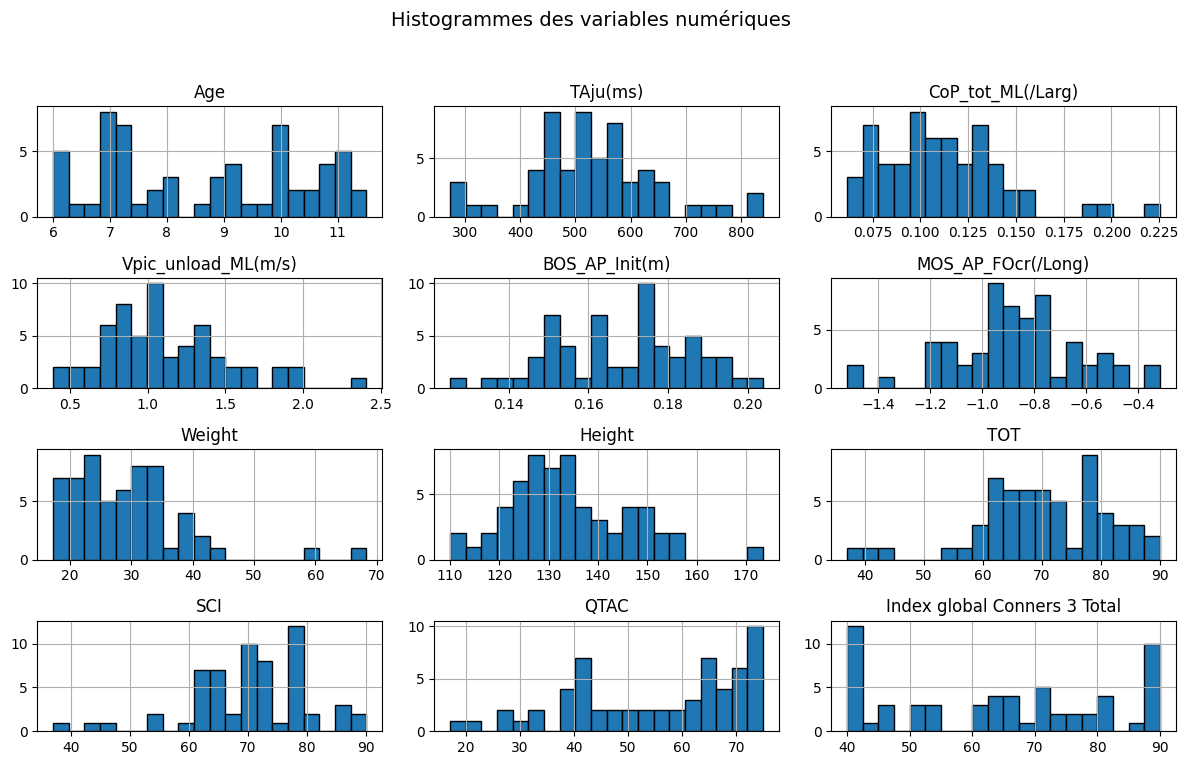

In [141]:
numeric_vars = ['Age', 'TAju(ms)', 'CoP_tot_ML(/Larg)', 'Vpic_unload_ML(m/s)','BOS_AP_Init(m)','MOS_AP_FOcr(/Long)','Weight', 'Height', 'TOT', 'SCI', 'QTAC', 'Index global Conners 3 Total']

plt.figure(figsize=(12, 8))
df[numeric_vars].hist(bins=20, figsize=(12,8), layout=(4,3), edgecolor='black') # Changed layout to (4,3) to accommodate 12 variables
plt.suptitle("Histogrammes des variables numériques", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Added to prevent overlapping titles
plt.show()


**🎻 Violin Plot (Répartition et densité)**


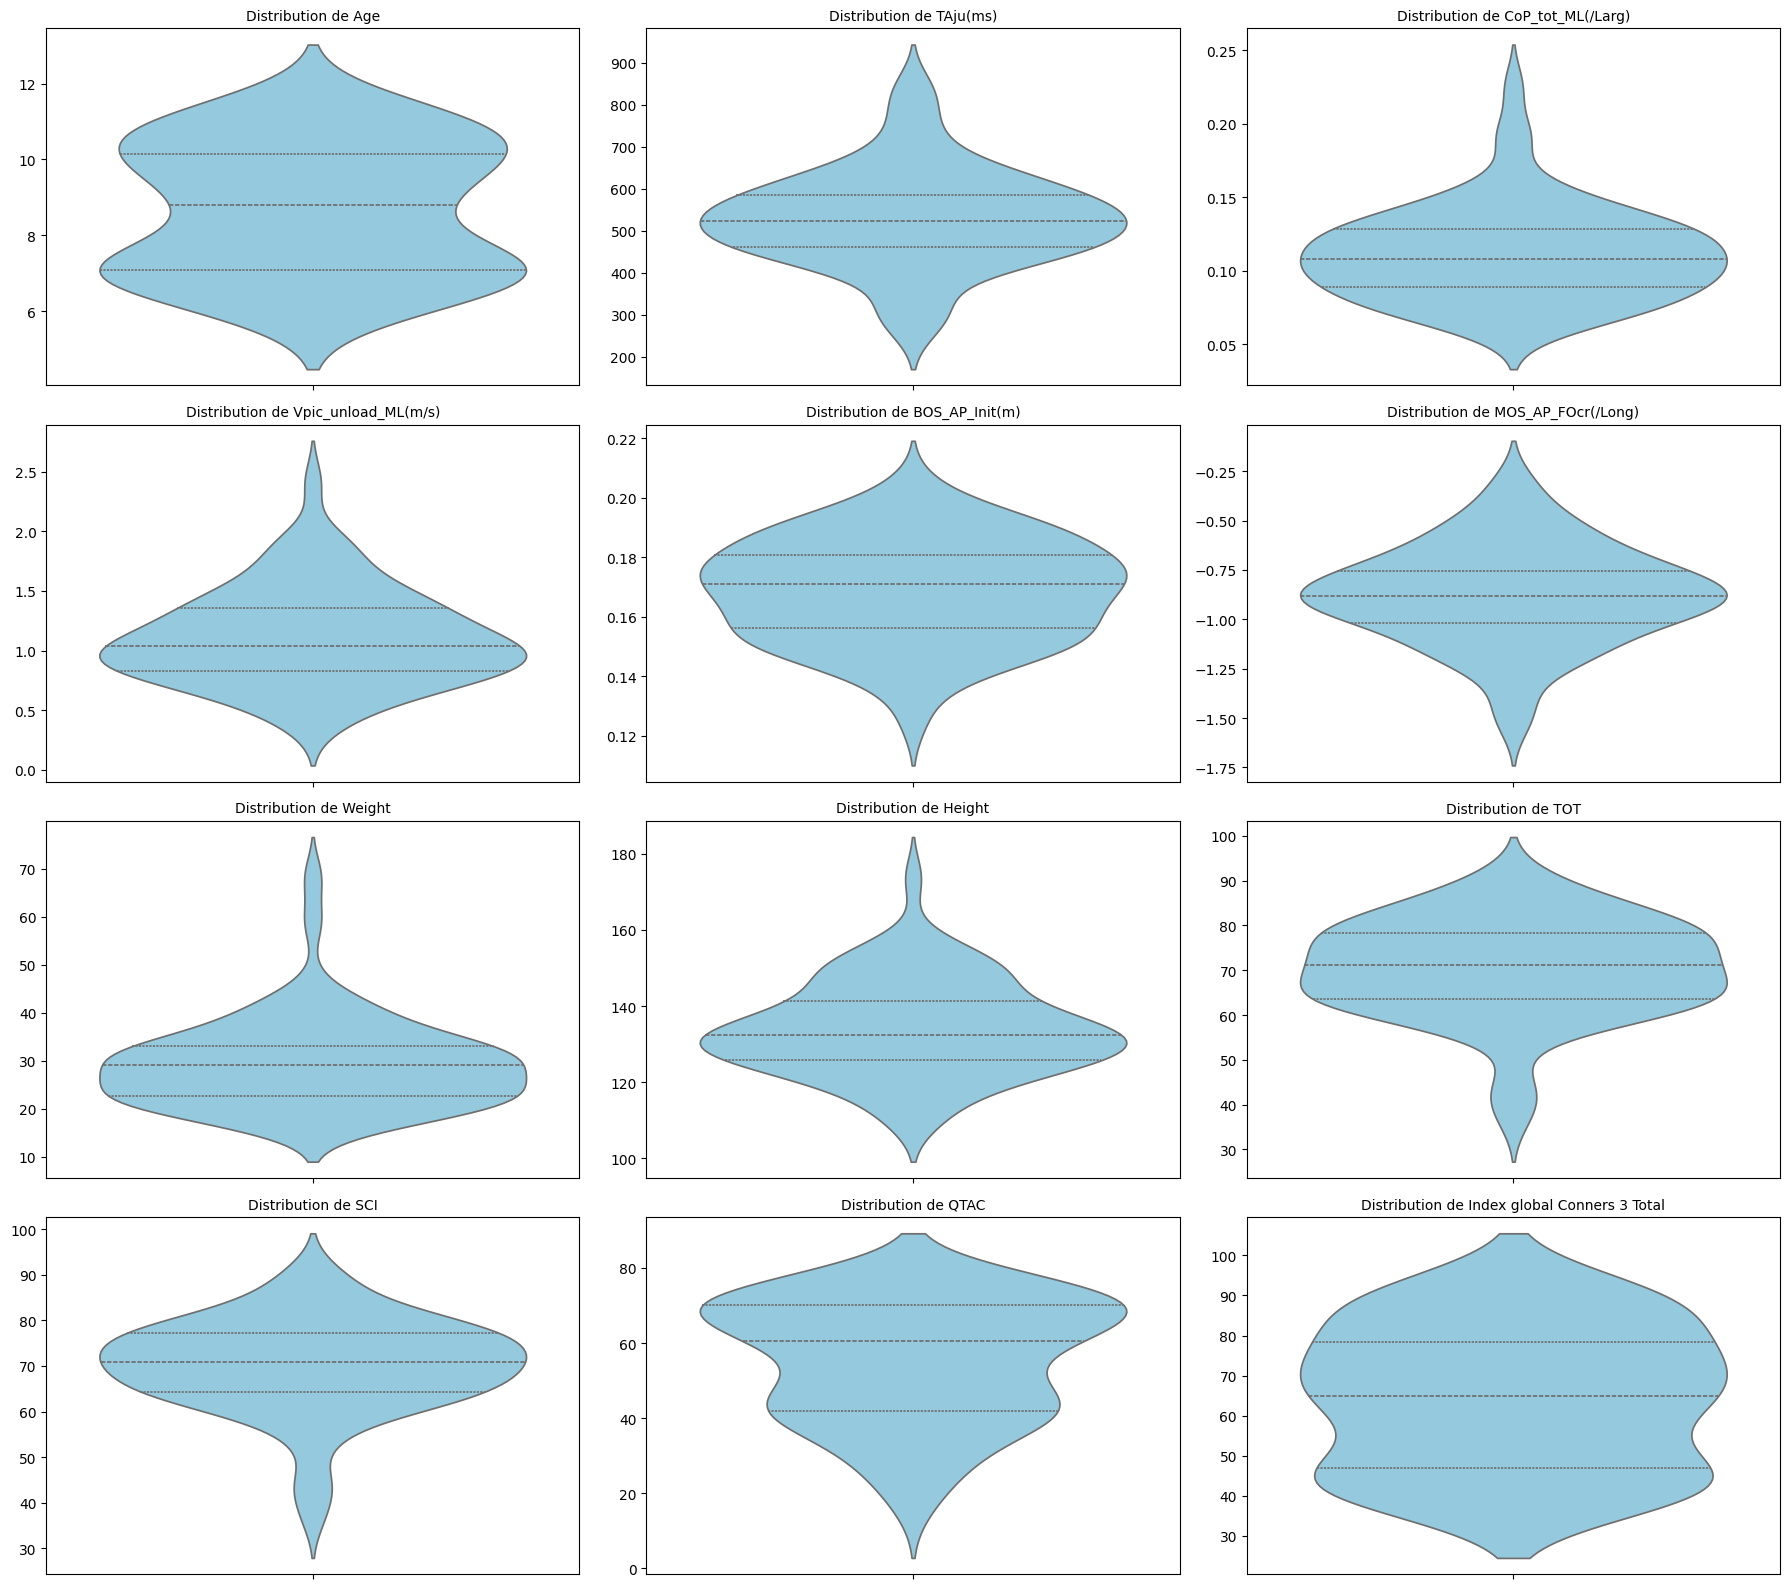

In [142]:
n_cols = 3  # 3 plots par ligne
n_rows = len(numeric_vars) // n_cols + (1 if len(numeric_vars) % n_cols != 0 else 0)

plt.figure(figsize=(18, 4 * n_rows))  # Largeur augmentée pour 3 plots

for i, var in enumerate(numeric_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.violinplot(y=df1[var], color='skyblue', inner='quartile')  # Affiche les quartiles
    plt.title(f"Distribution de {var}", fontsize=10)
    plt.ylabel('')

plt.tight_layout()
plt.show()

**🎯 Nuage de points 1D (Strip Plot)**

**Objectif :** Vérifier la répartition des observations.

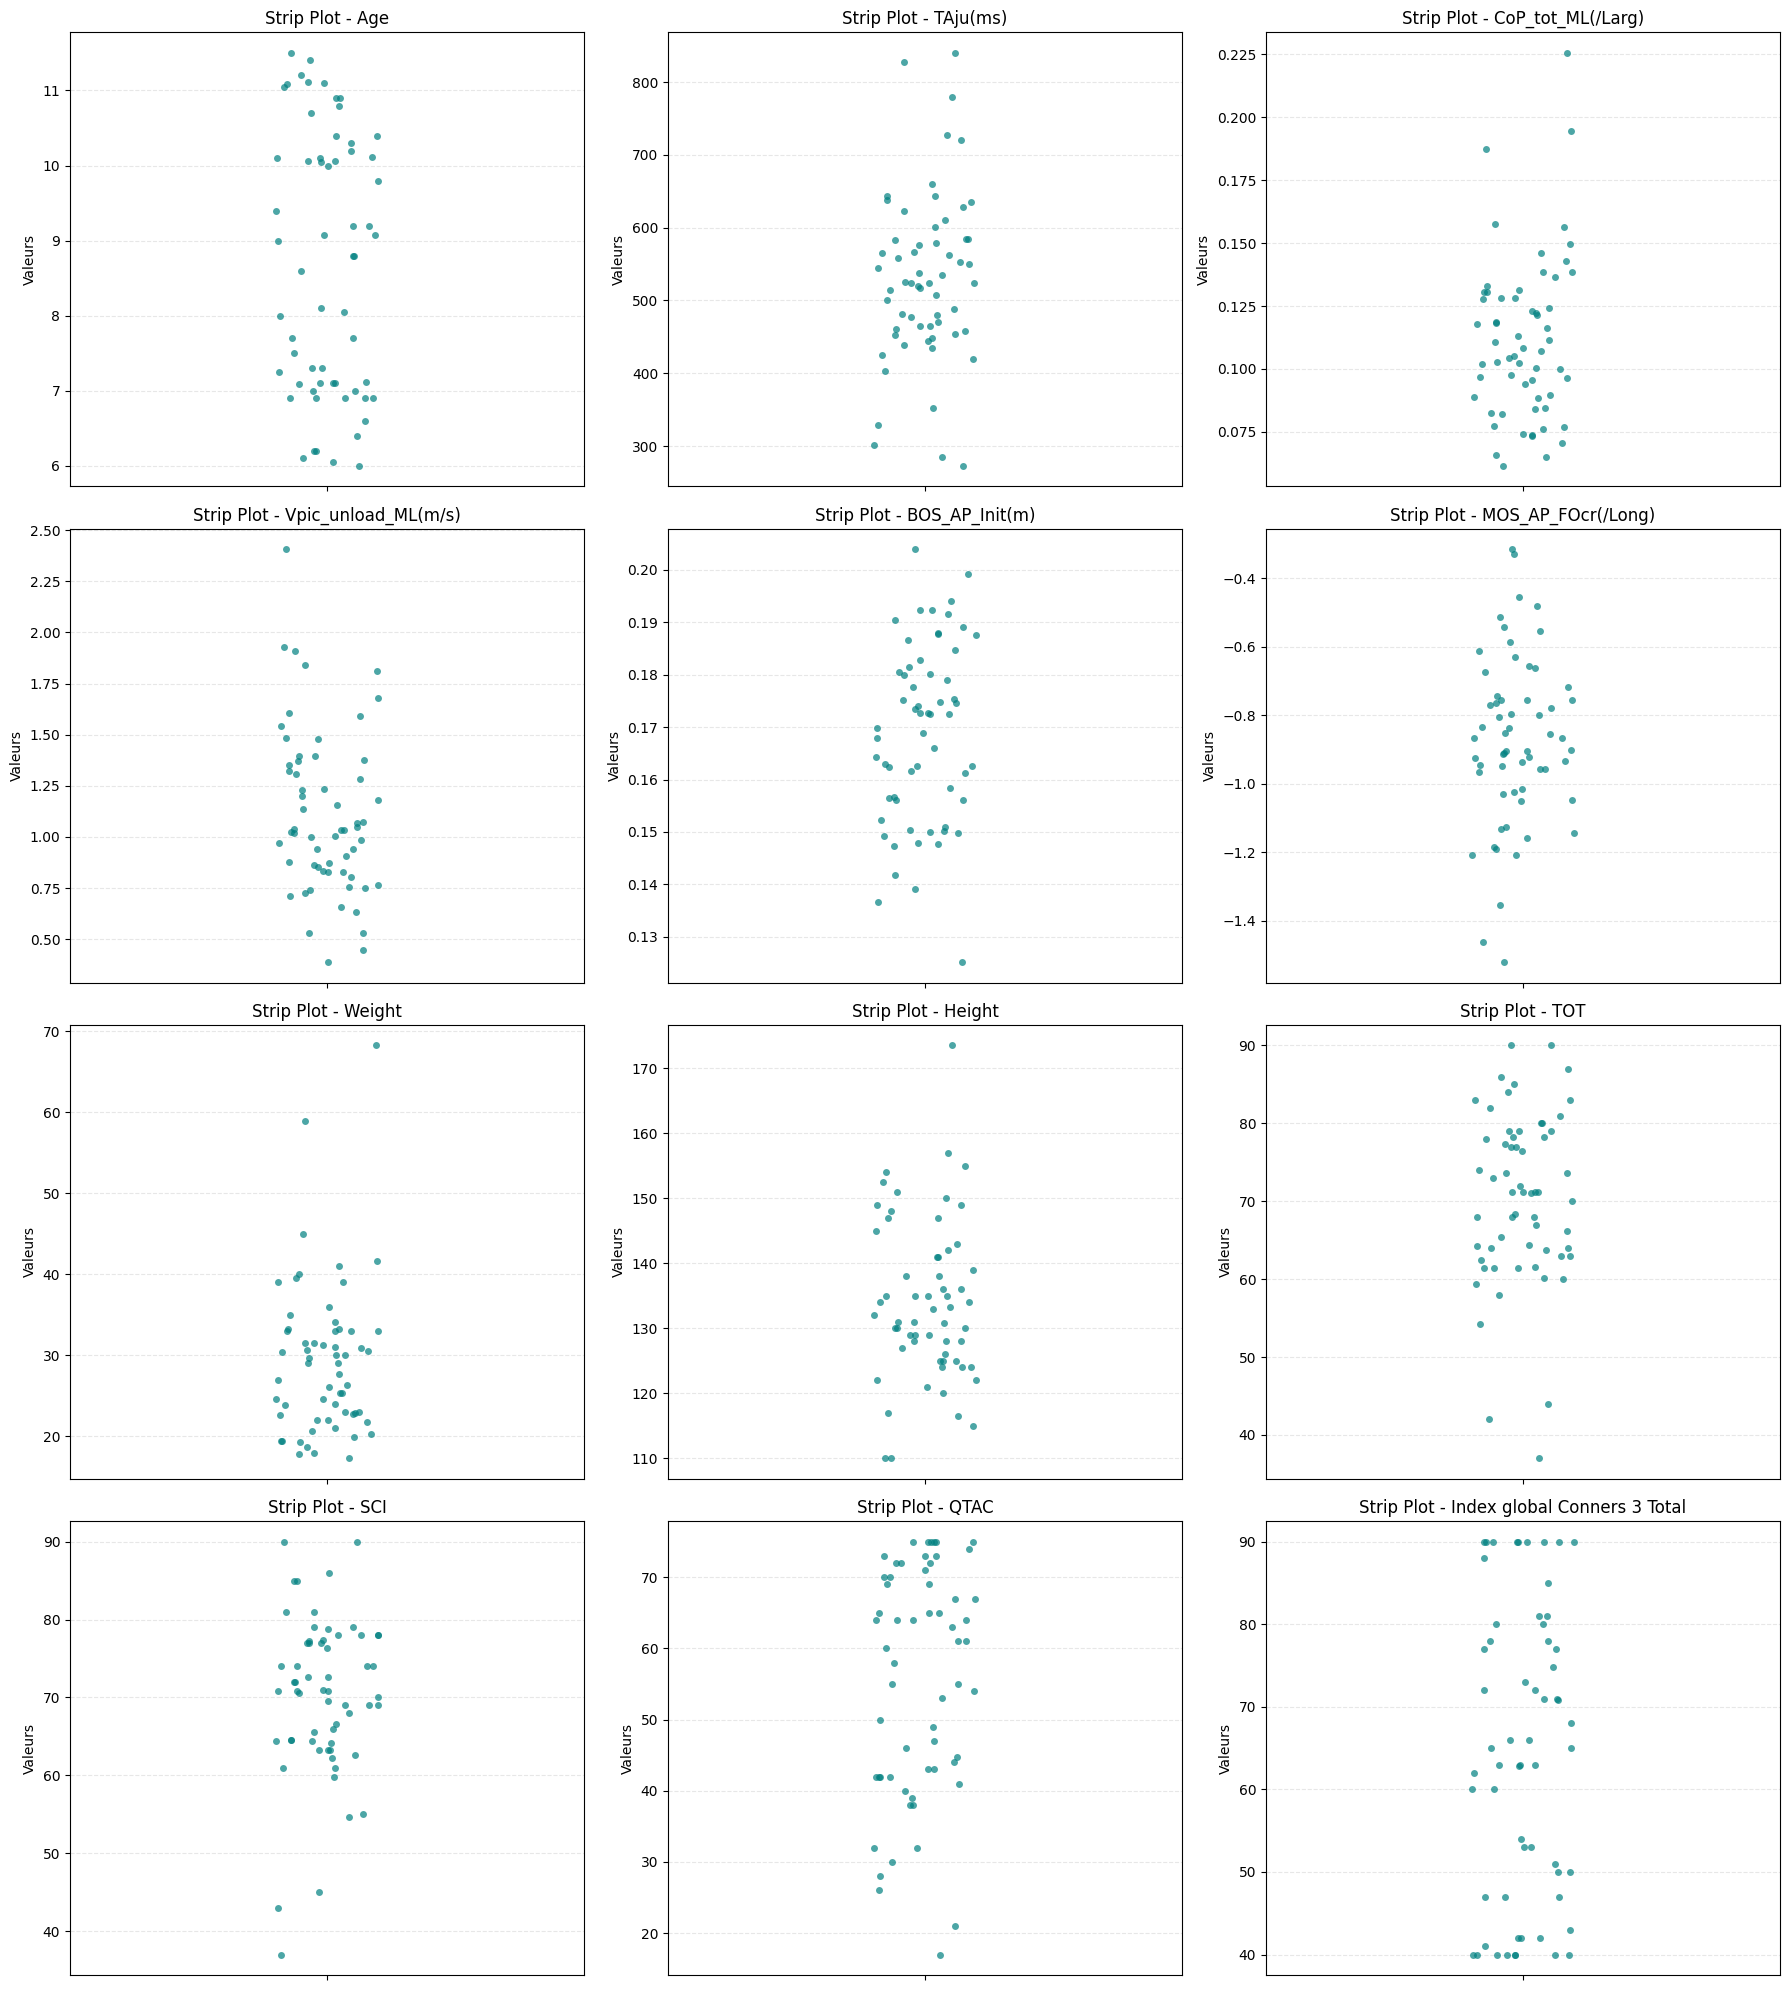

In [143]:
plt.figure(figsize=(18, 5 * n_rows))  # Taille adaptative

for i, var in enumerate(numeric_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.stripplot(y=df1[var], jitter=True, color='teal', alpha=0.7, size=5)
    plt.title(f"Strip Plot - {var}", fontsize=12)
    plt.ylabel('Valeurs')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**📈 ECDF (Empirical Cumulative Distribution Function)**

Objectif : Étudier la répartition des valeurs sous forme cumulative.

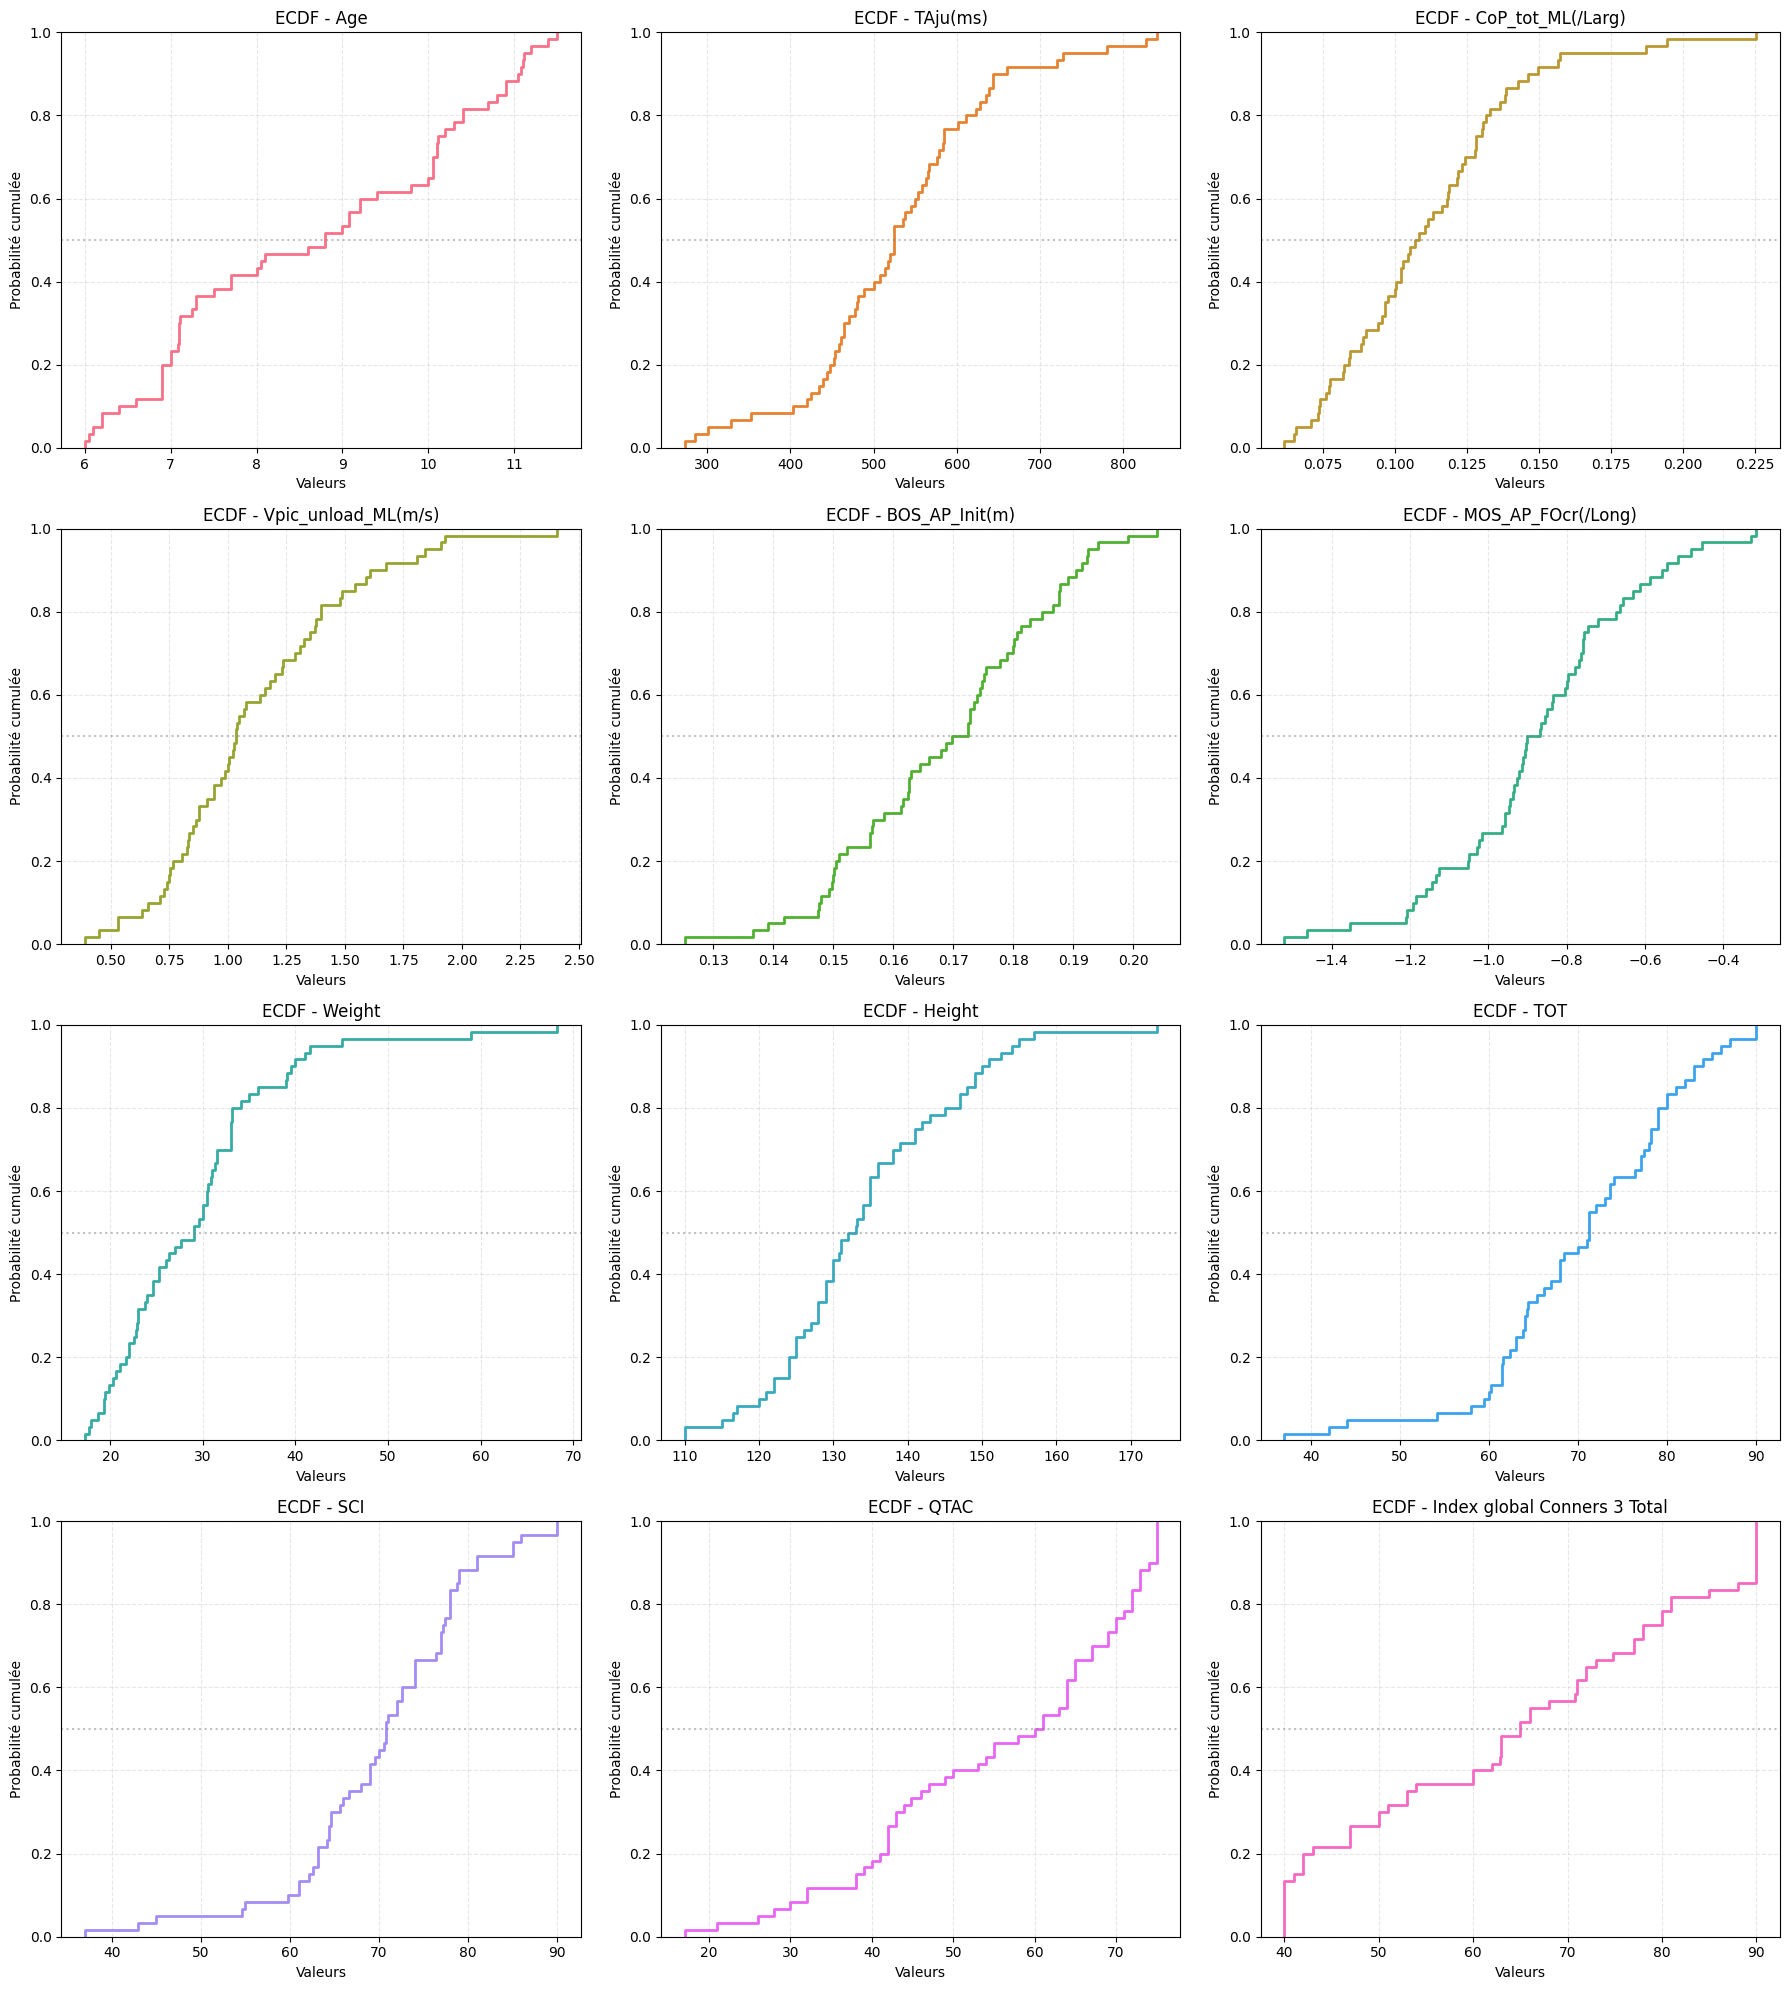

In [144]:
# Création de la figure
plt.figure(figsize=(18, 5 * n_rows))  # Largeur adaptée pour 3 colonnes

# Palette de couleurs distinctes
palette = sns.color_palette("husl", len(numeric_vars))

for i, var in enumerate(numeric_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.ecdfplot(data=df1, x=var, color=palette[i-1], linewidth=2)
    plt.title(f"ECDF - {var}", fontsize=12)
    plt.xlabel('Valeurs')
    plt.ylabel('Probabilité cumulée')
    plt.grid(True, linestyle='--', alpha=0.3)

    # Ajout d'une ligne à 50% pour la médiane
    plt.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**🔺 Diagramme de Pareto (Impact des valeurs)**

Objectif : Voir quelles valeurs ont un poids important.

In [145]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_vars) / n_cols))

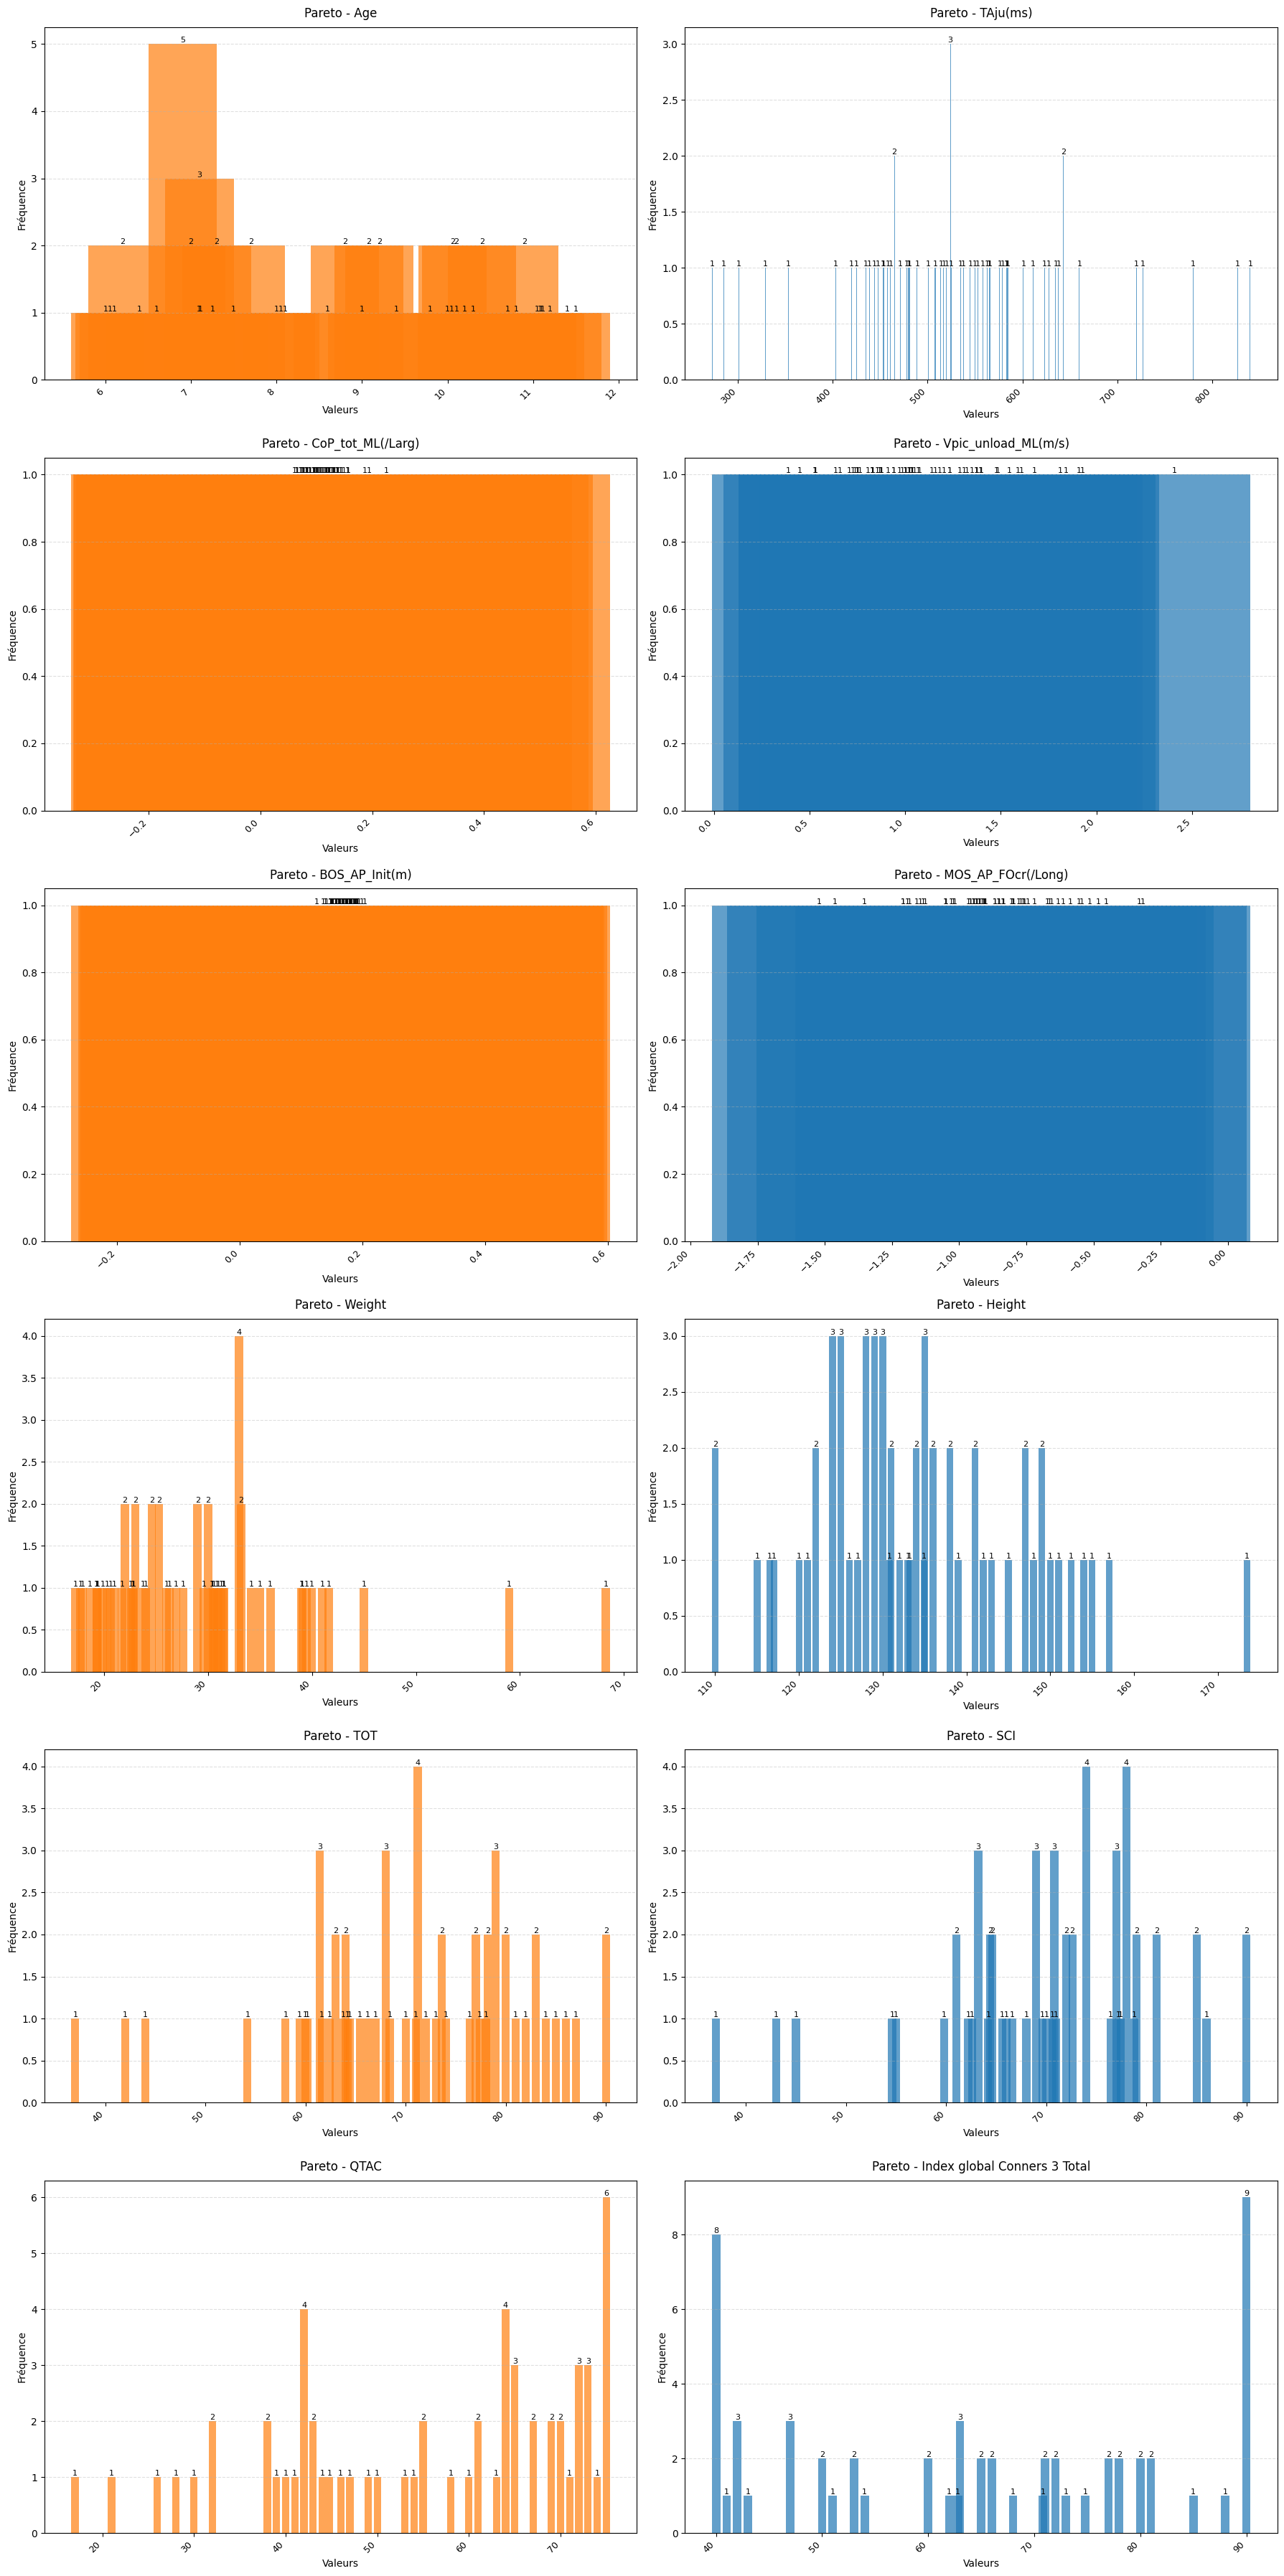

In [146]:
# Création de la figure
plt.figure(figsize=(18, 6 * n_rows))  # Taille adaptative
palette = sns.color_palette("tab10", n_cols)  # Palette de couleurs

for i, var in enumerate(numeric_vars, 1):
    plt.subplot(n_rows, n_cols, i)

    # Calcul des fréquences
    sorted_counts = Counter(df1[var]).most_common()
    values, counts = zip(*sorted_counts)

    # Diagramme de Pareto
    bars = plt.bar(values, counts, color=palette[i % n_cols], alpha=0.7)
    plt.title(f"Pareto - {var}", fontsize=12, pad=10)
    plt.xlabel('Valeurs')
    plt.ylabel('Fréquence')

    # Rotation des étiquettes pour lisibilité
    plt.xticks(rotation=45, ha='right', fontsize=9)

    # Ajout des valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height}',
                 ha='center', va='bottom', fontsize=8)

    # Grille et ajustements
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

plt.show()

Le diagramme de Pareto identifie rapidement les quelques valeurs cruciales qui représentent la majeure partie de l'impact total. Les barres les plus hautes à gauche indiquent les valeurs ayant le poids le plus important, et la courbe cumulative montre le pourcentage de l'impact total qu'elles représentent.

**📌 2. Variables Catégorielles**

Les variables catégorielles sont analysées via des diagrammes adaptés pour visualiser leurs fréquences.

📊 Diagramme en Barres (Répartition des catégories)


<ipython-input-147-833924efc9bd>:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




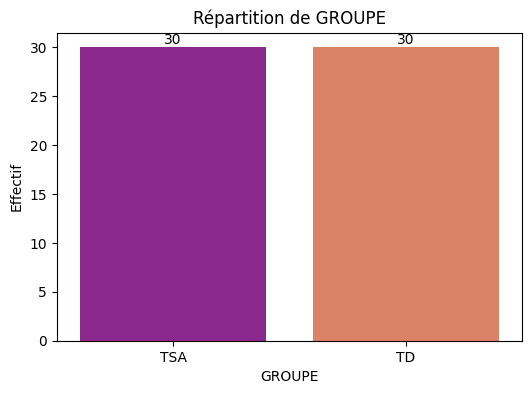

<ipython-input-147-833924efc9bd>:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




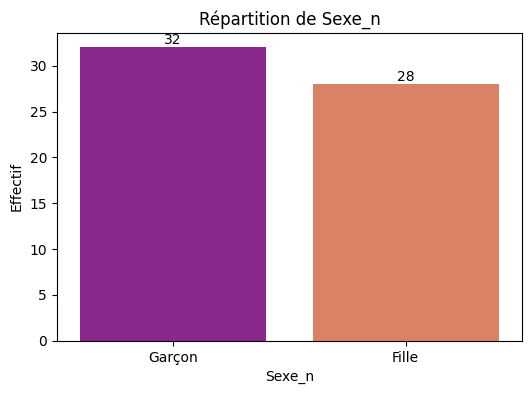

In [147]:
# Supposons que votre DataFrame s'appelle df1
cat_vars = ['GROUPE', 'Sexe_n']

# Créer un mapping pour l'encodage de la variable 'Sexe'
sexe_mapping = {1: 'Garçon', 2: 'Fille'}

# Appliquer le mapping à la colonne 'Sexe'
df['Sexe_n'] = df['Sexe'].map(sexe_mapping)

for var in cat_vars:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=df[var], palette='plasma')  # Utilisation de la palette 'viridis' pour des couleurs différentes
    plt.title(f"Répartition de {var}")
    plt.xlabel(var)
    plt.ylabel("Effectif")

    # Ajouter les étiquettes d'effectif sur chaque barre
    for p in ax.patches:
        ha = 'center'
        y = p.get_height()
        x = p.get_x() + p.get_width() / 2
        ax.annotate(f'{int(y)}', (x, y), ha=ha, va='bottom')

    plt.show()

c

**📈 Nuage de points (Scatter Plot)**

Question : Existe-t-il une relation linéaire ou non entre deux variables numériques ?

Paires de variables avec |r| > 0.5 :
                   Variable1                    Variable2  Corrélation
                         TOT                          SCI     0.979509
                         SCI                          COM     0.975427
                         TOT                          COM     0.961253
         Total_Affect social     Inter Sociale Reciproque     0.950465
                         SCI                          COG     0.917759
                         TOT                          RRB     0.904594
                         TOT                          COG     0.903813
                         COM                          COG     0.879515
                         SCI                          RRB     0.857043
                         SCI                          AWR     0.855511
                         RRB                          COM     0.832592
                         TOT                          AWR     0.829928
         Total_Affect social            

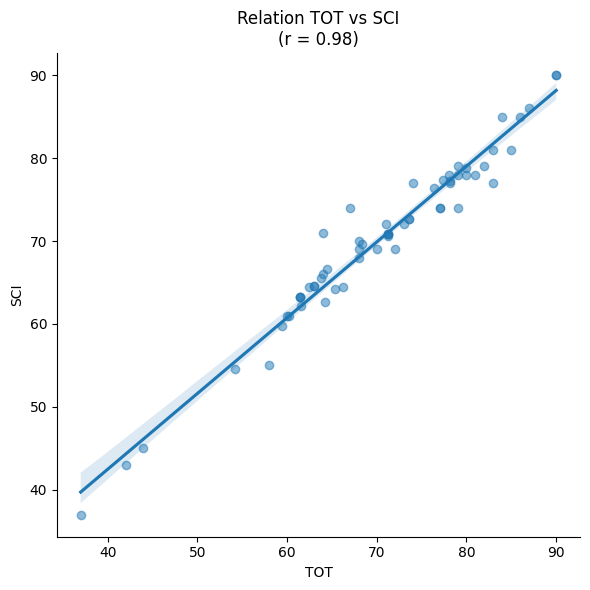

In [148]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul de la matrice de corrélation
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Filtrage des corrélations > 0.5 (en valeur absolue)
strong_corr = corr_matrix[abs(corr_matrix) > 0.5]

# 3. Masquage des doublons et de la diagonale
mask = np.triu(np.ones_like(strong_corr, dtype=bool))
filtered_corr = strong_corr.mask(mask)

# 4. Extraction des paires significatives
corr_pairs = filtered_corr.stack().reset_index()
corr_pairs.columns = ['Variable1', 'Variable2', 'Corrélation']
significant_pairs = corr_pairs[abs(corr_pairs['Corrélation']) > 0.5].sort_values(by='Corrélation', ascending=False)

# 5. Affichage des résultats
print("Paires de variables avec |r| > 0.5 :")
print(significant_pairs.to_string(index=False))


# 6. Option : Nuage de points pour la paire la plus corrélée
if not significant_pairs.empty:
    top_pair = significant_pairs.iloc[0]
    sns.lmplot(x=top_pair['Variable1'],
               y=top_pair['Variable2'],
               data=df,
               height=6,
               scatter_kws={'alpha':0.5})
    plt.title(f"Relation {top_pair['Variable1']} vs {top_pair['Variable2']}\n(r = {top_pair['Corrélation']:.2f})")
    plt.tight_layout()
    plt.show()

In [149]:
significant_pairs

,Variable1,Variable2,Corrélation
46,TOT,SCI,0.979509
36,SCI,COM,0.975427
43,TOT,COM,0.961253
49,Total_Affect social,Inter Sociale Reciproque,0.950465
35,SCI,COG,0.917759
45,TOT,RRB,0.904594
42,TOT,COG,0.903813
22,COM,COG,0.879515
38,SCI,RRB,0.857043
34,SCI,AWR,0.855511


🎯 Carte de densité 2D (2D Density Plot)

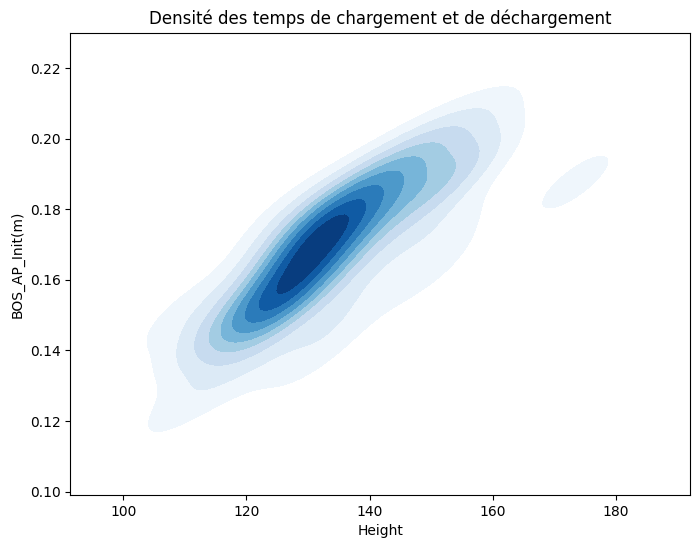

In [150]:
plt.figure(figsize=(8,6))
sns.kdeplot(x=df['Height'], y=df['BOS_AP_Init(m)'], cmap='Blues', fill=True)
plt.title("Densité des temps de chargement et de déchargement")
plt.show()


**📌 2. Une Variable Numérique et une Variable Catégorielle**

Ici, on veut voir si une catégorie influence une variable numérique.

**📊 Boîtes à moustaches parallèles (Parallel Box Plots)**

Question : Les valeurs numériques varient-elles selon les catégories ?

<ipython-input-151-2937e67415dc>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




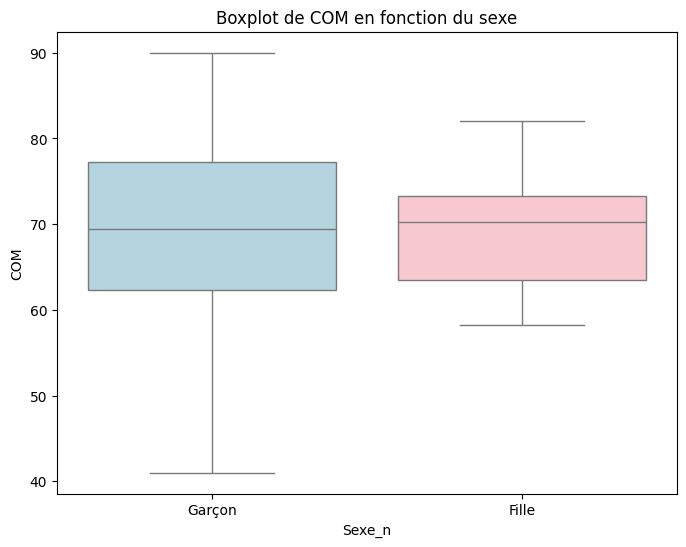

In [151]:
# prompt: boxplot de Sexe et COM en changeant la couleur du boxplot en fonction du sexe et en ignorant les outlier

plt.figure(figsize=(8, 6))
sns.boxplot(x='Sexe_n', y='COM', data=df, showfliers=False, palette={'Garçon': 'lightblue', 'Fille': 'pink'})
plt.title("Boxplot de COM en fonction du sexe")
plt.show()


**🎻 Diagrammes en violon parallèles (Parallel Violin Plots)**

Question : Quelle est la distribution des valeurs pour chaque catégorie ?

<ipython-input-152-0d1381feaa85>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




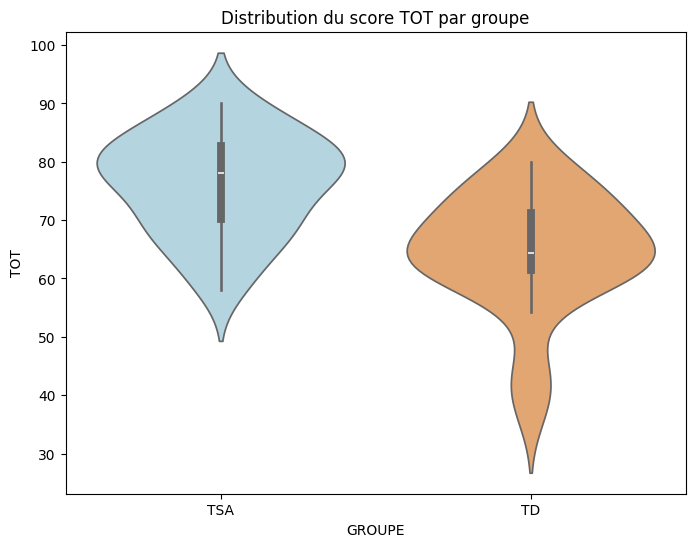

In [152]:
plt.figure(figsize=(8,6))
sns.violinplot(x=df['GROUPE'], y=df['TOT'], palette={'TSA': 'lightblue', 'TD': 'sandybrown'})
plt.title("Distribution du score TOT par groupe")
plt.show()


**📊 Histogrammes superposés ou côte à côte (Stacked or Side-by-Side Histograms)**

**Question :** Comment se comparent les distributions selon une catégorie ?


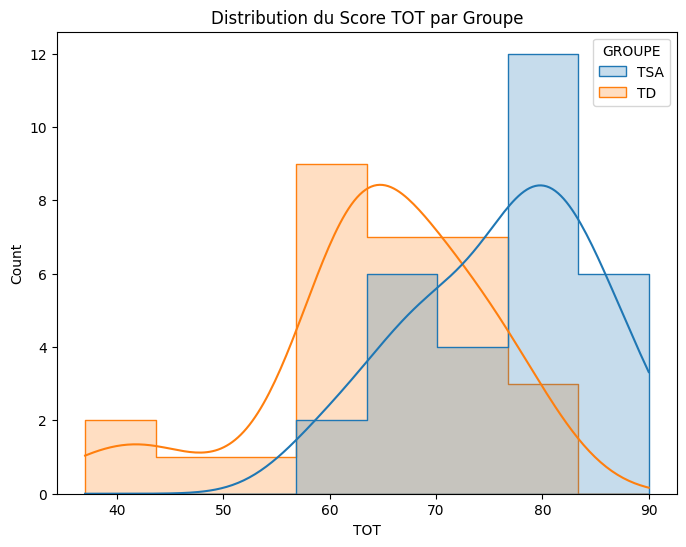

In [153]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='TOT', hue='GROUPE', kde=True, element="step", common_norm=False)
plt.title("Distribution du Score TOT par Groupe")
plt.show()

<ipython-input-154-7b54aa207a8e>:2: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


<ipython-input-154-7b54aa207a8e>:3: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




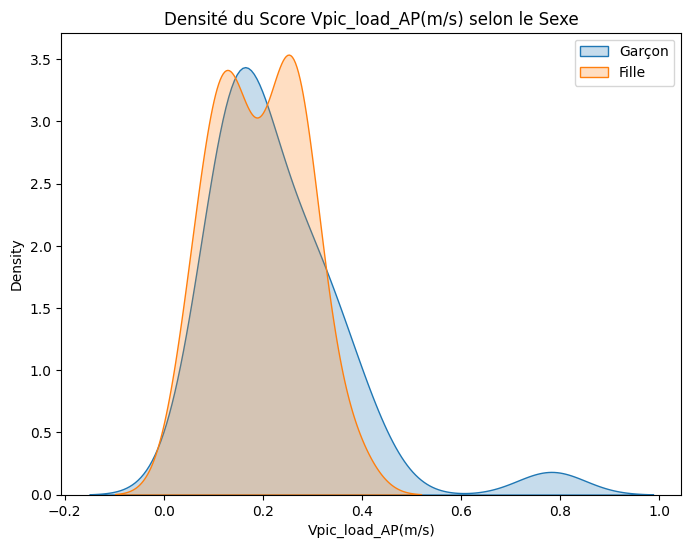

In [154]:
plt.figure(figsize=(8,6))
sns.kdeplot(df[df['Sexe_n'] == 'Garçon']['Vpic_load_AP(m/s)'], label='Garçon', shade=True)
sns.kdeplot(df[df['Sexe_n'] == 'Fille']['Vpic_load_AP(m/s)'], label='Fille', shade=True)
plt.title("Densité du Score Vpic_load_AP(m/s) selon le Sexe")
plt.legend()
plt.show()


**📊 Diagrammes en barres groupées (Grouped Bar Charts)**

Question : Comment une moyenne varie-t-elle selon des catégories ?

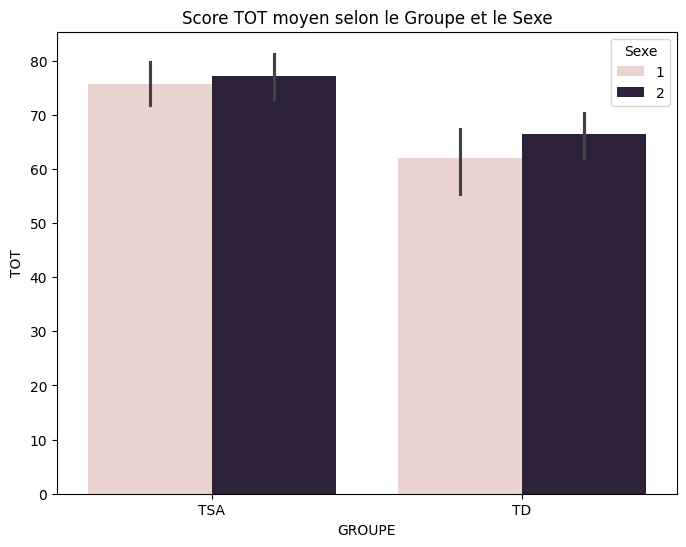

In [155]:
plt.figure(figsize=(8,6))
sns.barplot(x=df['GROUPE'], y=df['TOT'], hue=df['Sexe'])
plt.title("Score TOT moyen selon le Groupe et le Sexe")
plt.show()


ct

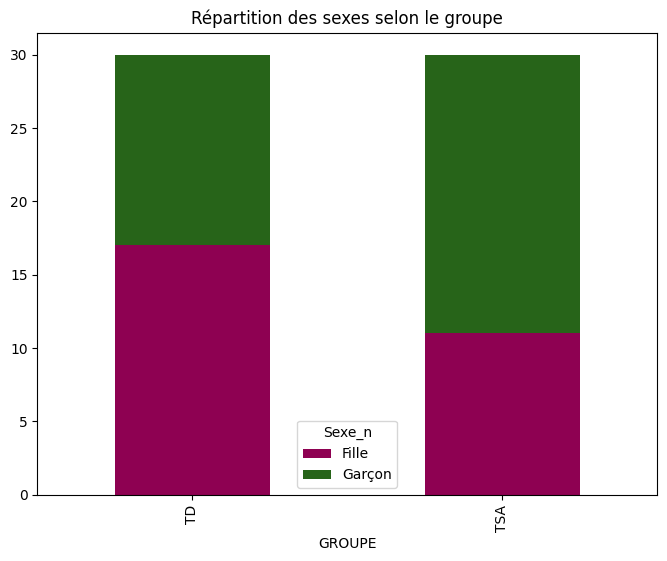

In [156]:
table = pd.crosstab(df['GROUPE'], df['Sexe_n'])
table.plot(kind='bar', stacked=True, colormap='PiYG', figsize=(8,6))
plt.title("Répartition des sexes selon le groupe")
plt.show()


**Tableau croisé dynamique (Crosstab) avec carte de chaleur (Heatmap)**

Question : Y a-t-il une relation marquée entre deux catégories ?

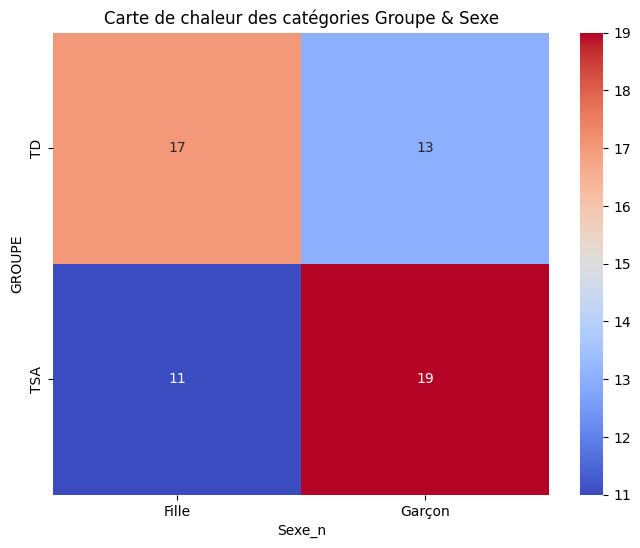

In [157]:
cross_tab = pd.crosstab(df['GROUPE'], df['Sexe_n'])
plt.figure(figsize=(8,6))
sns.heatmap(cross_tab, annot=True, cmap='coolwarm')
plt.title("Carte de chaleur des catégories Groupe & Sexe")
plt.show()


<Figure size 800x600 with 0 Axes>

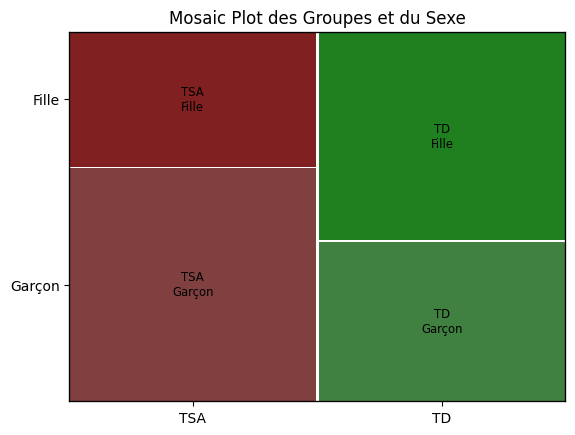

In [158]:
from statsmodels.graphics.mosaicplot import mosaic

plt.figure(figsize=(8,6))
mosaic(df, ['GROUPE', 'Sexe_n'])
plt.title("Mosaic Plot des Groupes et du Sexe")
plt.show()


**Analyse Multivariée**

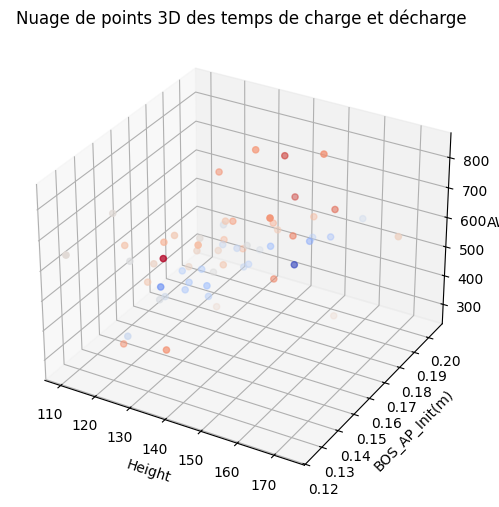

In [159]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Height'], df['BOS_AP_Init(m)'], df['TAju(ms)'], c=df['AWR'], cmap='coolwarm')

ax.set_xlabel('Height')
ax.set_ylabel('BOS_AP_Init(m)')
ax.set_zlabel('AWR')
plt.title('Nuage de points 3D des temps de charge et décharge')
plt.show()


**Nuage de points avec codage couleur/taille**

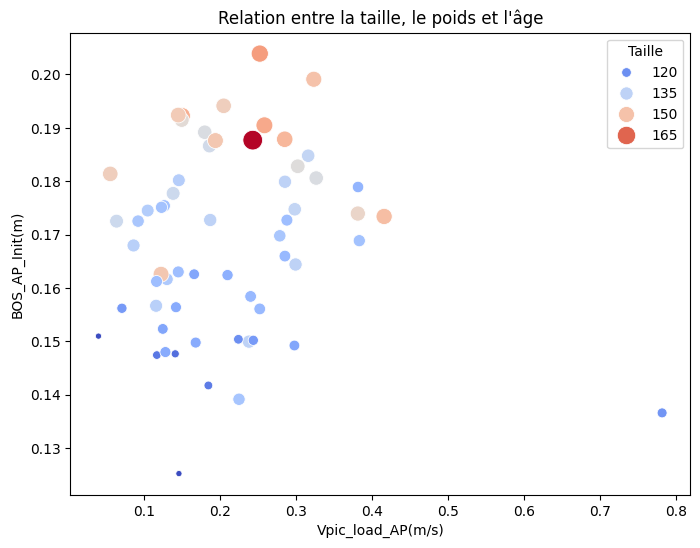

In [160]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Vpic_load_AP(m/s)'], y=df['BOS_AP_Init(m)'], hue=df['Height'], size=df['Height'], sizes=(20, 200), palette="coolwarm")
plt.title("Relation entre la taille, le poids et l'âge")
plt.xlabel("Vpic_load_AP(m/s)")
plt.ylabel("BOS_AP_Init(m)")
plt.legend(title="Taille")
plt.show()


**Coordonnées parallèles (Parallel Coordinates Plot)**

Exemple : Comparaison des variables CoP_loadAP, CoP_load_ML, MOS_AP_FOcr

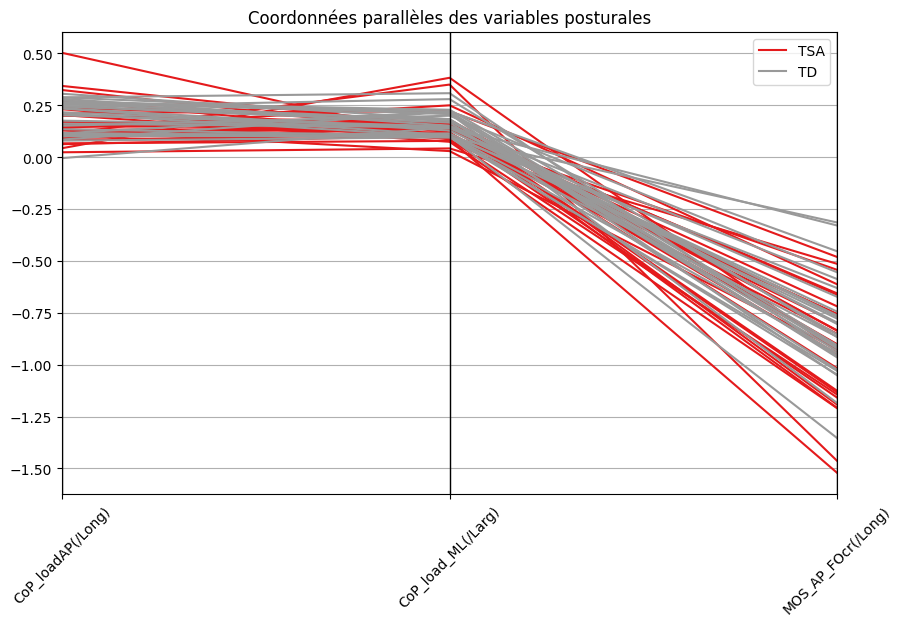

In [161]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(10, 6))
parallel_coordinates(df[['GROUPE', 'CoP_loadAP(/Long)', 'CoP_load_ML(/Larg)', 'MOS_AP_FOcr(/Long)']], class_column='GROUPE', colormap=plt.get_cmap("Set1"))
plt.title("Coordonnées parallèles des variables posturales")
plt.xticks(rotation=45)
plt.show()


In [162]:
import plotly.express as px

fig = px.sunburst(df, path=['Sexe', 'GROUPE'], values='Index global Conners 3 Total', title="Diagramme Sunburst de l'Index Global Conners 3 par Groupe et Sexe")
fig.show()



Pairplot

In [178]:
# ----------------------------------------
# 1. Install/Enable Libraries (Run Once)
# ----------------------------------------
# No installation usually needed in Colab for these, but enable widgets extension
!pip install -q pandas plotly ipywidgets # Ensure they are installed
from google.colab import output
output.enable_custom_widget_manager() # Important for ipywidgets in Colab

# ----------------------------------------
# 2. Import Libraries
# ----------------------------------------
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout
from IPython.display import display, clear_output

# ----------------------------------------

# **** END: REPLACE THIS WITH YOUR DATAFRAME ****


# ----------------------------------------
# 4. Define Variables of Interest
# ----------------------------------------
variables = ['TOT','SCI', 'COM', 'Total_Affect social', 'Index global Conners 3 Total',
             'COG','RRB', 'AWR',  'Communication', 'Height', 'BOS_AP_Init(m)',
             'Vpic_load_AP(m/s)', 'CoP_loadAP(/Long)', 'MOT','Age',
             'Vpic_load_ML(m/s)', 'CoP_load_ML(/Larg)']

# Filter df to only include specified variables (optional, but good practice)
# Ensure all variables exist in the df
available_variables = [var for var in variables if var in df.columns]
if len(available_variables) != len(variables):
    print("Warning: Some specified variables not found in DataFrame columns.")
    print("Using available variables:", available_variables)
    variables = available_variables # Use only the ones that exist

# You might want to keep only these columns if your df is very large
# df_subset = df[variables].copy()
# Or work with the full df if you need other columns for filtering/coloring later
df_subset = df # Let's use the original df for now

# ----------------------------------------
# 5. Create Interactive Widgets
# ----------------------------------------

# Dropdown for plot type
plot_type_widget = widgets.Dropdown(
    options=['Histogram', 'Box Plot', 'Scatter Plot'],
    value='Histogram',
    description='Plot Type:',
    disabled=False,
)

# Dropdown for single variable (for Histogram, Box Plot)
var1_widget = widgets.Dropdown(
    options=variables,
    value=variables[0] if variables else None, # Set default value
    description='Variable:',
    disabled=False,
)

# Dropdown for X-axis variable (for Scatter Plot)
x_widget = widgets.Dropdown(
    options=variables,
    value=variables[0] if variables else None, # Set default value
    description='X-Axis:',
    disabled=False,
)

# Dropdown for Y-axis variable (for Scatter Plot)
y_widget = widgets.Dropdown(
    options=variables,
    value=variables[1] if len(variables) > 1 else (variables[0] if variables else None), # Set different default
    description='Y-Axis:',
    disabled=False,
)

# (Optional) Dropdown for Color variable (for Scatter Plot)
# Add 'None' to allow scatter plot without color encoding
color_options = ['None'] + variables
color_widget = widgets.Dropdown(
    options=color_options,
    value='None',
    description='Color By:',
    disabled=False,
)


# Output widget to display the plot
plot_output = widgets.Output()

# ----------------------------------------
# 6. Define Function to Update Plot
# ----------------------------------------
def update_plot(change):
    """Redraws the plot based on widget values."""
    with plot_output: # Direct output to the plot_output widget
        clear_output(wait=True) # Clear previous plot

        plot_type = plot_type_widget.value
        var1 = var1_widget.value
        x_var = x_widget.value
        y_var = y_widget.value
        color_var = color_widget.value if color_widget.value != 'None' else None # Handle 'None' case

        try:
            if plot_type == 'Histogram':
                if var1:
                    fig = px.histogram(df_subset, x=var1, title=f'Histogram of {var1}')
                    fig.show()
                else:
                    print("Please select a variable.")

            elif plot_type == 'Box Plot':
                if var1:
                    fig = px.box(df_subset, y=var1, title=f'Box Plot of {var1}')
                    fig.show()
                else:
                    print("Please select a variable.")

            elif plot_type == 'Scatter Plot':
                if x_var and y_var:
                    fig = px.scatter(df_subset, x=x_var, y=y_var, color=color_var,
                                     title=f'Scatter Plot: {x_var} vs {y_var}' + (f' (Colored by {color_var})' if color_var else ''))
                    fig.show()
                else:
                     print("Please select both X and Y axis variables.")

        except Exception as e:
            print(f"An error occurred during plotting: {e}")


# --------------------------------------------------
# 7. Define Function to Update Widget Visibility
# --------------------------------------------------
def update_widget_visibility(change):
    """Shows/hides widgets based on selected plot type."""
    plot_type = plot_type_widget.value
    if plot_type in ['Histogram', 'Box Plot']:
        # Show var1_widget, hide x_widget, y_widget, color_widget
        controls_box.children = [plot_type_widget, var1_widget]
    elif plot_type == 'Scatter Plot':
        # Hide var1_widget, show x_widget, y_widget, color_widget
        controls_box.children = [plot_type_widget, x_widget, y_widget, color_widget]
    else:
        # Default or error case: show only plot type selector
         controls_box.children = [plot_type_widget]

    # Trigger a plot update after changing visibility,
    # because the relevant widgets might have changed
    update_plot({}) # Pass an empty dict as change object


# ----------------------------------------
# 8. Link Widgets to Update Functions
# ----------------------------------------
# When plot type changes, update visibility AND the plot
plot_type_widget.observe(update_widget_visibility, names='value')
plot_type_widget.observe(update_plot, names='value')

# When other widgets change, just update the plot
var1_widget.observe(update_plot, names='value')
x_widget.observe(update_plot, names='value')
y_widget.observe(update_plot, names='value')
color_widget.observe(update_plot, names='value')


# ----------------------------------------
# 9. Layout and Display Dashboard
# ----------------------------------------

# Use a VBox to initially hold controls. Its children will be updated by update_widget_visibility
controls_box = VBox([])

# Main layout: controls on top, plot below
dashboard = VBox([controls_box, plot_output])

# Initial setup of widget visibility and plot draw
update_widget_visibility({}) # Set initial widget visibility
update_plot({}) # Draw initial plot

# Display the dashboard
print("--- Interactive Dashboard ---")
display(dashboard)

--- Interactive Dashboard ---
